In [90]:
# import all the 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import cross_val_score,train_test_split
from sklearn.metrics import accuracy_score,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline

In [91]:
# load the dataset
dataset=pd.read_csv('concrete_data.csv')
dataset.sample(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
484,446.0,24.0,79.0,162.0,10.3,967.0,712.0,56,54.77
801,252.0,0.0,0.0,185.0,0.0,1111.0,784.0,28,19.69
918,145.0,0.0,179.0,202.0,8.0,824.0,869.0,28,10.54
537,480.0,0.0,0.0,192.0,0.0,936.2,712.2,28,43.94
519,284.0,15.0,141.0,179.0,5.5,842.0,801.0,28,43.73


In [92]:
# Box-Cox Does not work With with null/0/negative values. we need to check if the dataset contains null/0 values.

dataset.isna().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [93]:
dataset.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [94]:
# From the description we can see that the dataset has minimun values 0. 
# so here we cannot apply box-cox. of we want then we need to preprocess the dataset and fill with some values
# But From the domain knowledge. there might be a change that the row must have 0 for the specific answer
# therefore for adjustment we will add a small value to it (0.0000000001) to all the elements in the dataset. 
# this will fix the 0 error also there will not be any huge change in the dataset

dataset=dataset+0.0000001

In [95]:
dataset.describe()
# Now the 0 Error is fixed.

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1.030000e+03,1.030000e+03,1030.000000,1.030000e+03,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,7.389583e+01,5.418835e+01,181.567282,6.204660e+00,972.918932,773.580486,45.662136,35.817961
std,104.506364,8.627934e+01,6.399700e+01,21.354219,5.973841e+00,77.753954,80.175980,63.169912,16.705742
min,102.000000,1.000000e-07,1.000000e-07,121.800000,1.000000e-07,801.000000,594.000000,1.000000,2.330000
25%,192.375000,1.000000e-07,1.000000e-07,164.900000,1.000000e-07,932.000000,730.950000,7.000000,23.710000
50%,272.900000,2.200000e+01,1.000000e-07,185.000000,6.400000e+00,968.000000,779.500000,28.000000,34.445000
75%,350.000000,1.429500e+02,1.183000e+02,192.000000,1.020000e+01,1029.400000,824.000000,56.000000,46.135000
max,540.000000,3.594000e+02,2.001000e+02,247.000000,3.220000e+01,1145.000000,992.600000,365.000000,82.600000


In [96]:
# Split the dataset into Train Test Split
X_train,X_test,y_train,y_test=train_test_split(dataset.iloc[:,:(len(dataset.columns)-1)],dataset.iloc[:,-1],test_size=0.25,random_state=42)

In [97]:
X_train

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
221,166.1,1.000000e-07,1.633000e+02,176.5,4.500000e+00,1058.6,780.1,28.0
235,213.8,9.810000e+01,2.450000e+01,181.7,6.700000e+00,1066.0,785.5,14.0
547,333.0,1.000000e-07,1.000000e-07,192.0,1.000000e-07,931.2,842.6,7.0
499,491.0,2.600000e+01,1.230000e+02,210.0,3.900000e+00,882.0,699.0,28.0
595,186.2,1.241000e+02,1.000000e-07,185.7,1.000000e-07,1083.4,764.3,28.0
...,...,...,...,...,...,...,...,...
87,286.3,2.009000e+02,1.000000e-07,144.7,1.120000e+01,1004.6,803.7,3.0
330,246.8,1.000000e-07,1.251000e+02,143.3,1.200000e+01,1086.8,800.9,14.0
466,190.3,1.000000e-07,1.252000e+02,166.6,9.900000e+00,1079.0,798.9,100.0
121,475.0,1.188000e+02,1.000000e-07,181.1,8.900000e+00,852.1,781.5,28.0


In [98]:
y_train

221    21.54
235    17.84
547    23.40
499    55.55
595    17.60
       ...  
87     24.40
330    42.22
466    33.56
121    68.30
860    38.46
Name: Strength, Length: 772, dtype: float64

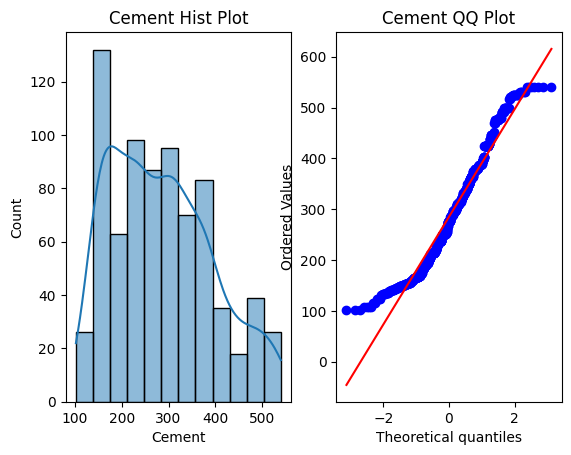

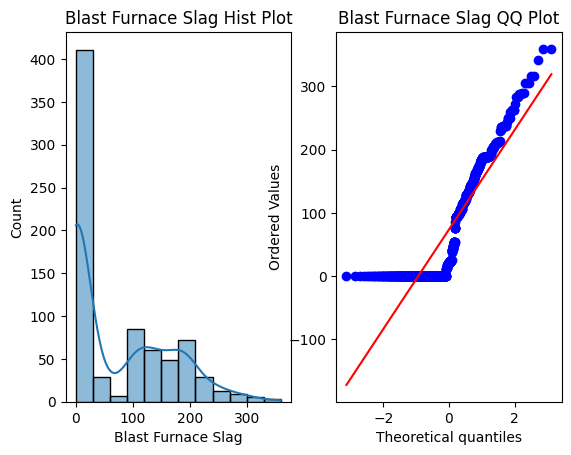

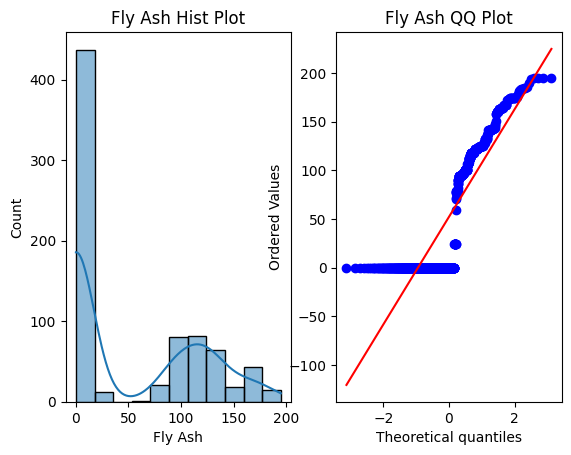

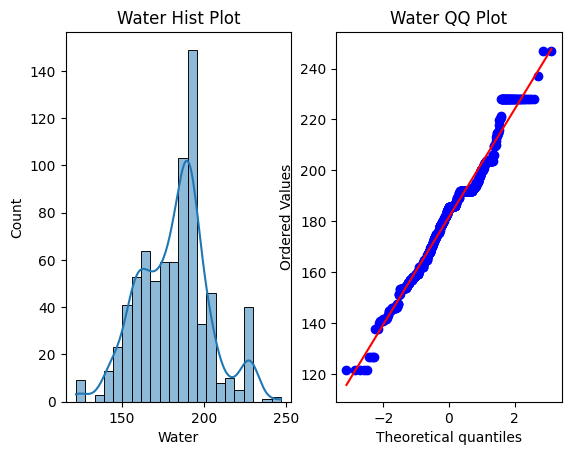

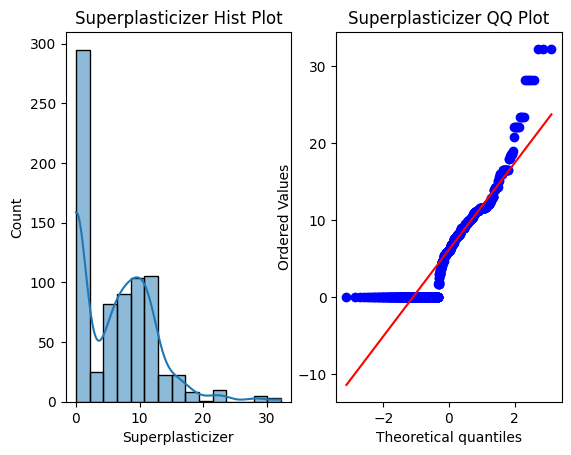

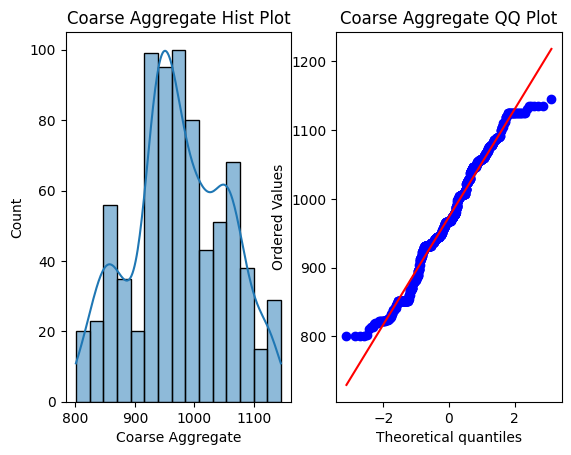

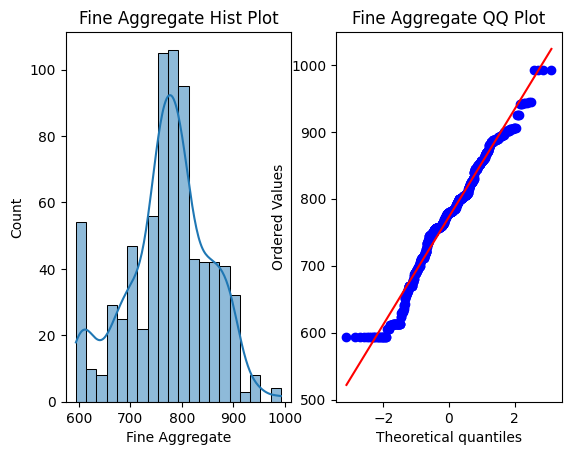

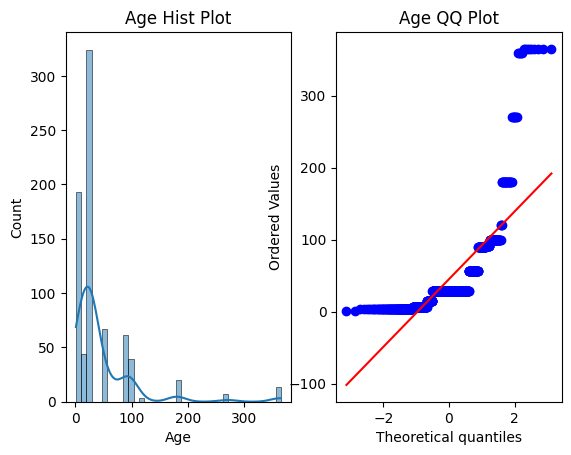

In [99]:
# Now lets Plot all the columns of the initial dataset

for col in X_train.columns:
    plt.Figure(figsize=(14,4))
    plt.subplot(121)
    plt.title(f'{col} Hist Plot')
    sns.histplot(X_train[col],kde=True)

    plt.subplot(122)
    stats.probplot(X_train[col],plot=plt,dist='norm')
    plt.title(f'{col} QQ Plot')
    plt.show()

In [100]:
# Now Lets Train a Linear Regression Model and test its Accuracy and r2_score

pipe=Pipeline([
    ('regression',LinearRegression())
])

pipe.fit(X_train,y_train)
y_predicted=pipe.predict(X_test)

print('r2_score:',r2_score(y_true=y_test,y_pred=y_predicted))
lr=LinearRegression()
print('cross_val_score:',np.mean(cross_val_score(estimator=lr,X=dataset.iloc[:,:len(dataset.columns)-1],y=dataset.iloc[:,-1],scoring='r2')))


r2_score: 0.6249829353885576
cross_val_score: 0.46099404916628595


In [101]:
def transformer(transformation):

    X = dataset.iloc[:, :-1]
    y = dataset.iloc[:, -1]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

    # Transformation
    pt = PowerTransformer(method=transformation)
    X_train_t = pt.fit_transform(X_train)
    X_test_t  = pt.transform(X_test)

    X_train_t = pd.DataFrame(X_train_t, columns=X.columns, index=X_train.index)
    X_test_t  = pd.DataFrame(X_test_t,  columns=X.columns, index=X_test.index)

    # Plots
    for col in X.columns:
        plt.figure(figsize=(40,20))

        plt.subplot(121)
        sns.histplot(X_train[col], kde=True)
        plt.title(f'{col} Before {transformation}')

        plt.subplot(122)
        sns.histplot(X_train_t[col], kde=True)
        plt.title(f'{col} After {transformation}')

        plt.show()

    # Model
    model = LinearRegression()
    model.fit(X_train_t, y_train)
    y_pred = model.predict(X_test_t)

    print("Test R2:", r2_score(y_test, y_pred))

    # Cross-validation (CORRECT)
    pipe = Pipeline([
        ('transform', PowerTransformer(method=transformation)),
        ('regression', LinearRegression())
    ])

    cv_r2 = cross_val_score(
        pipe, X, y, cv=5, scoring='r2'
    ).mean()

    print("CV R2:", cv_r2)


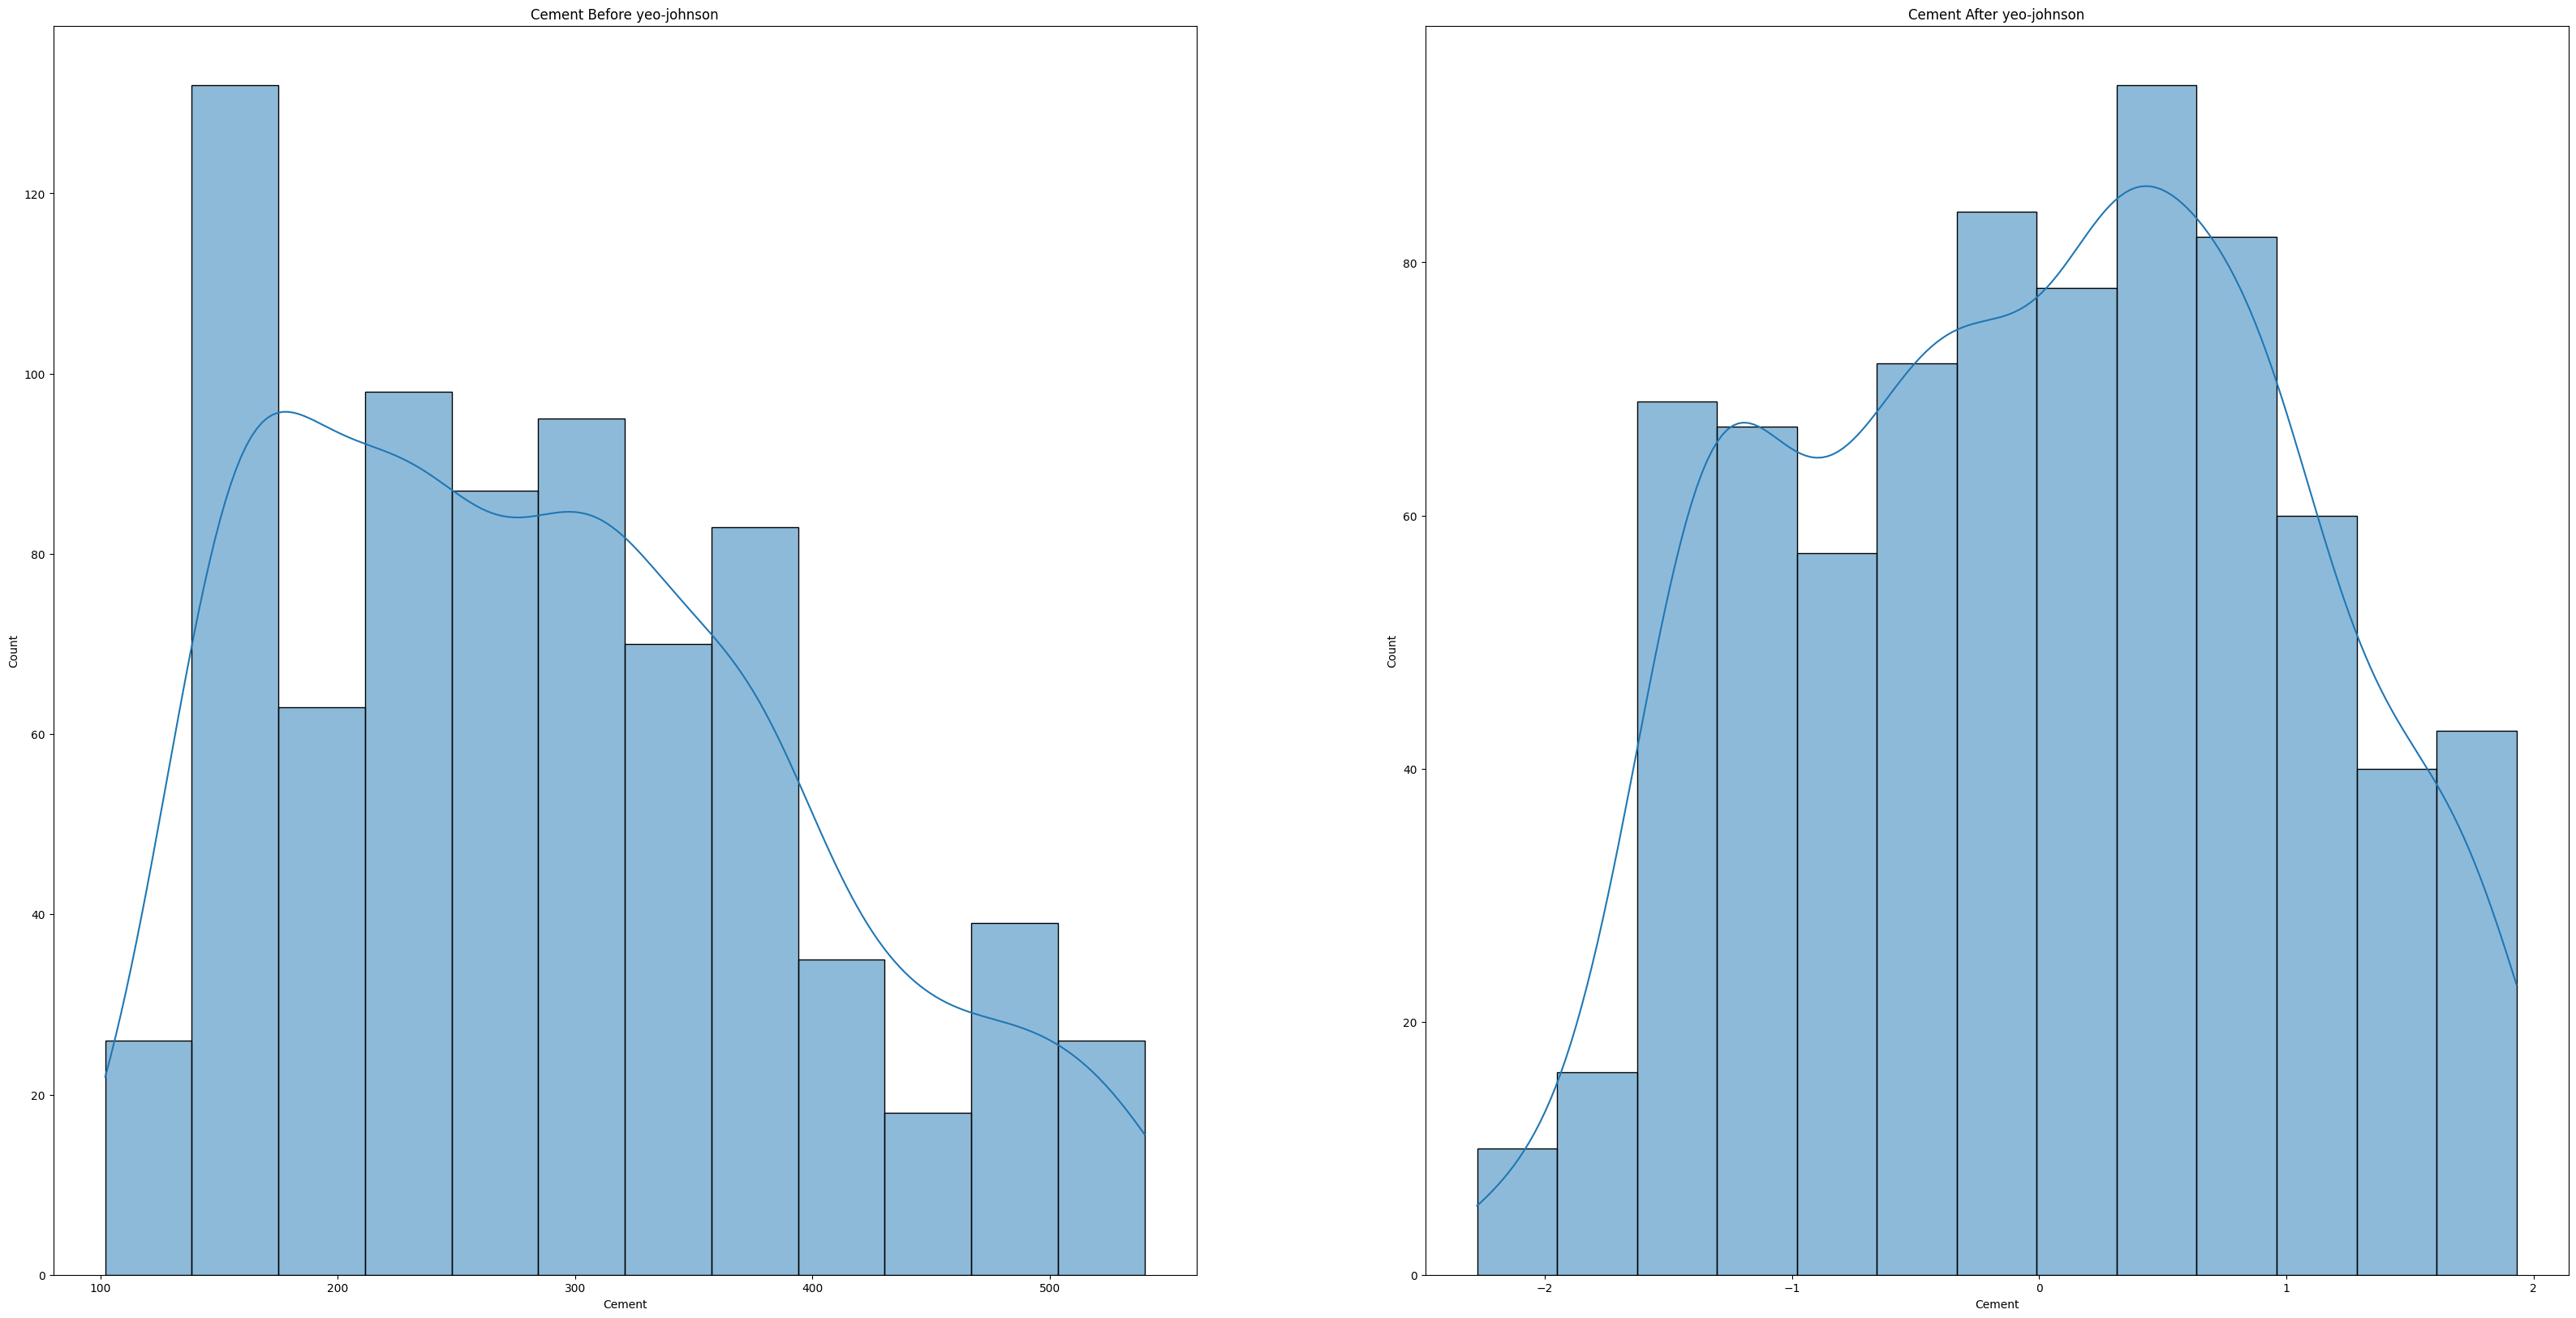

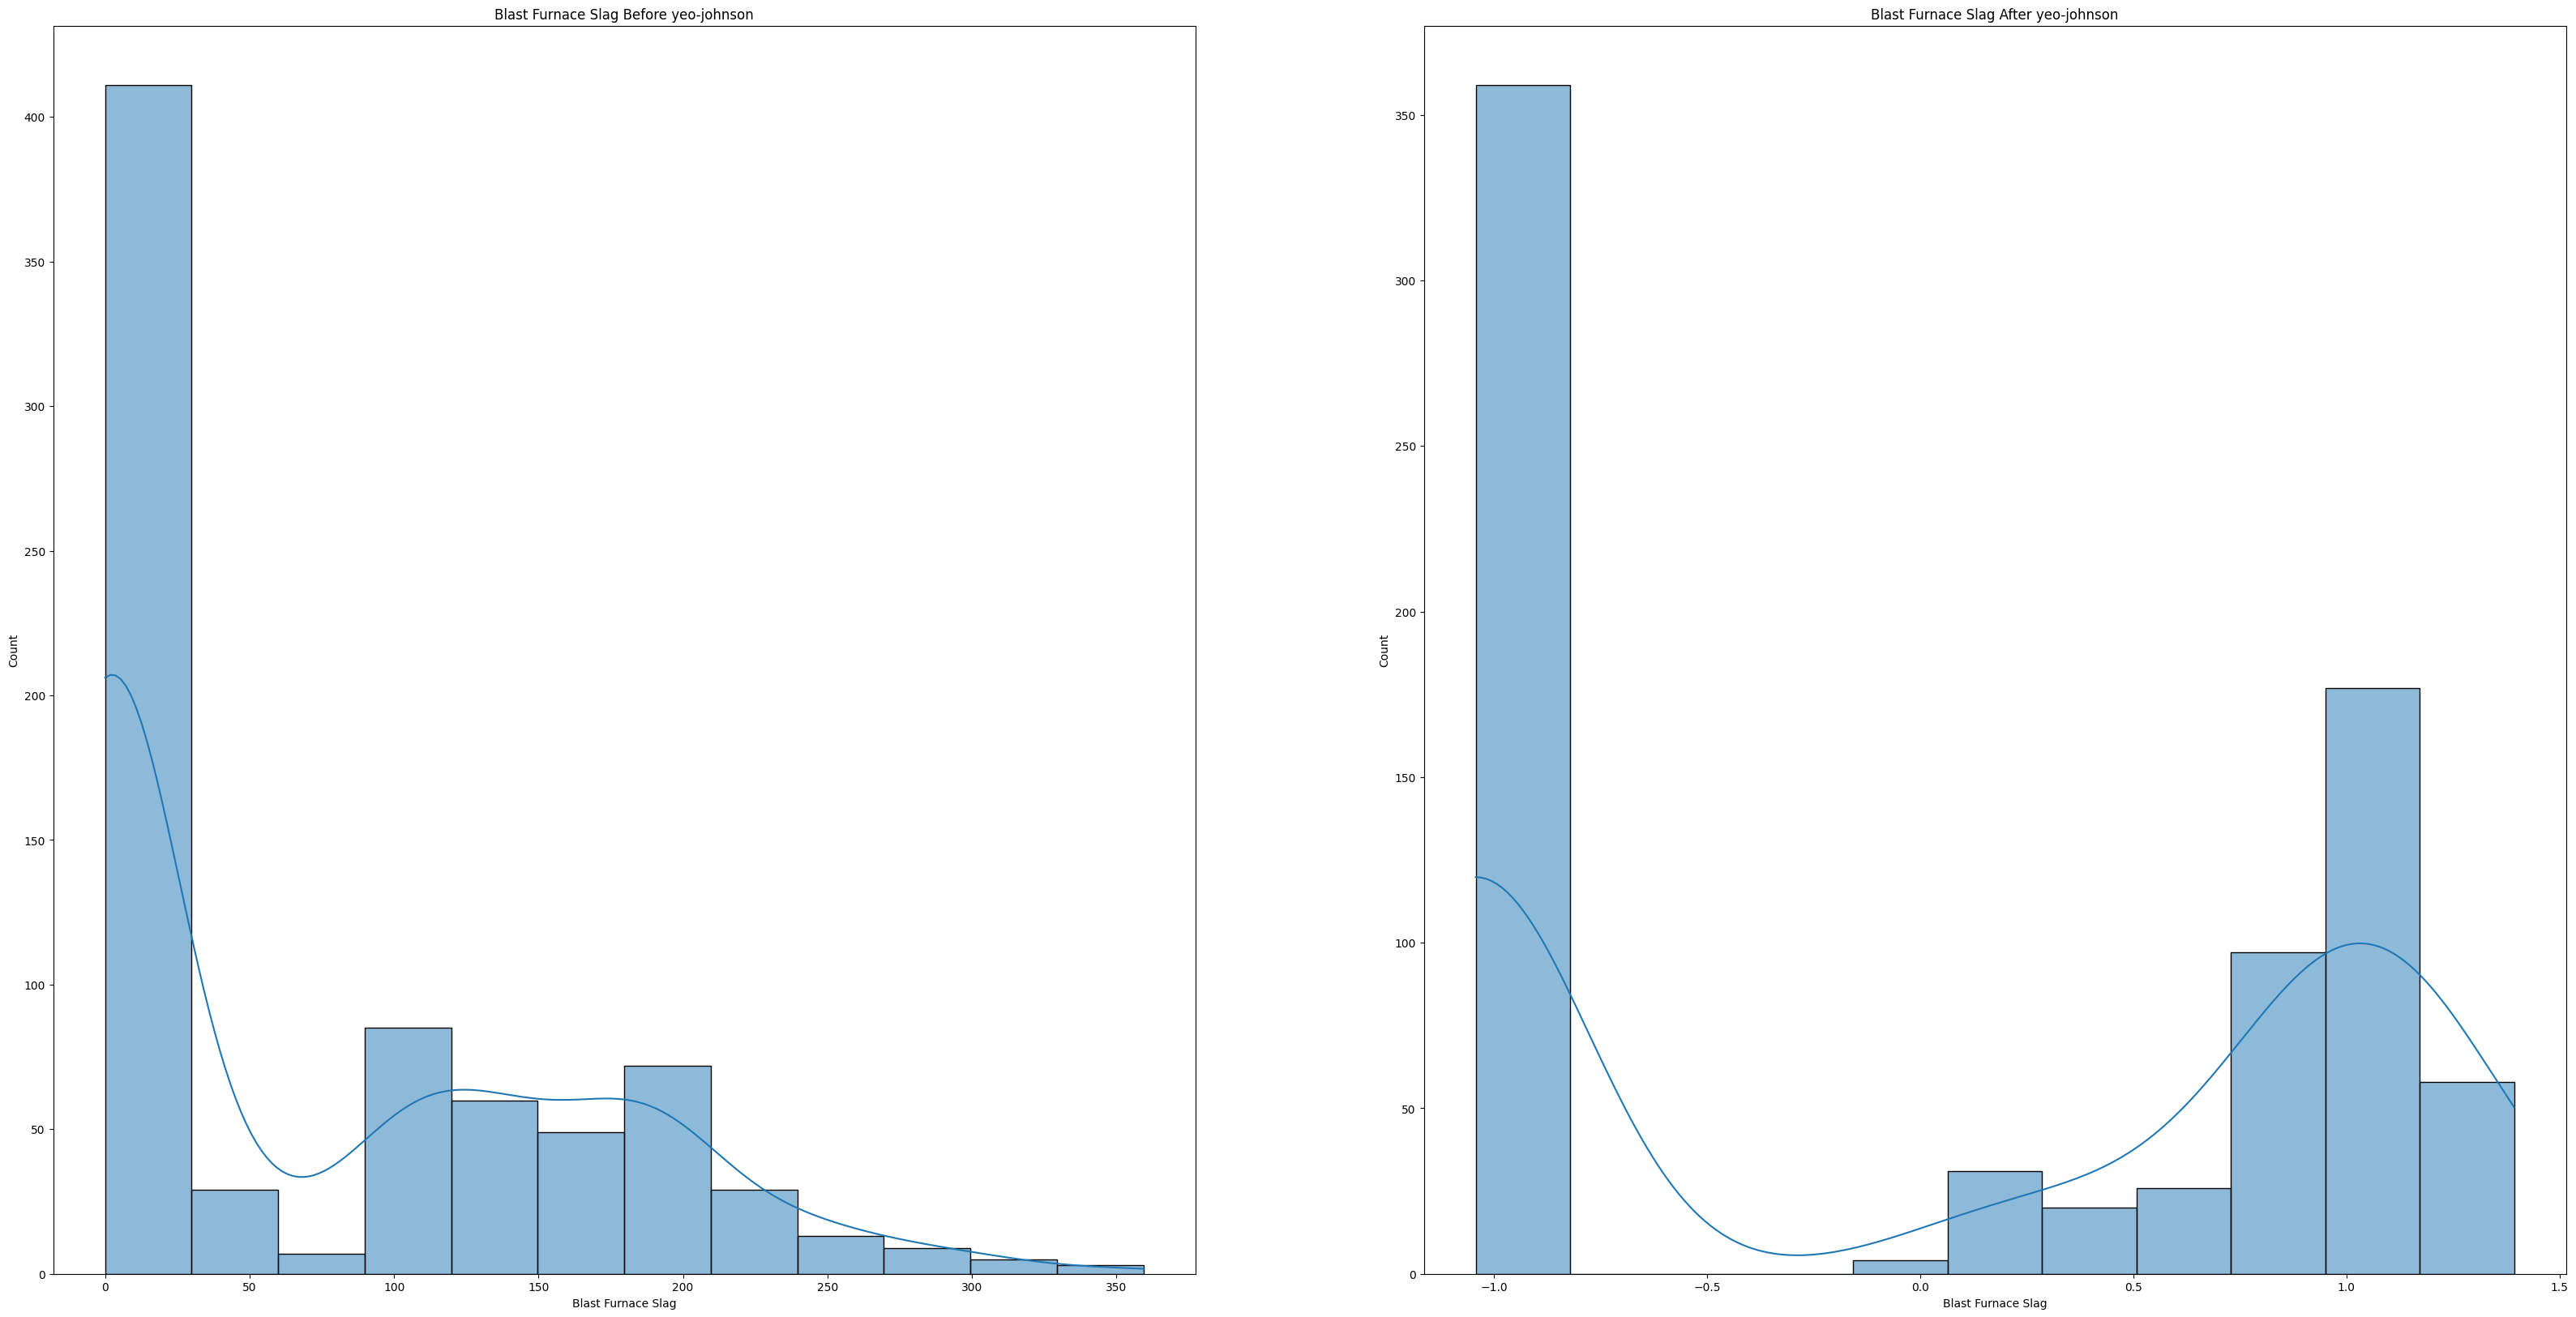

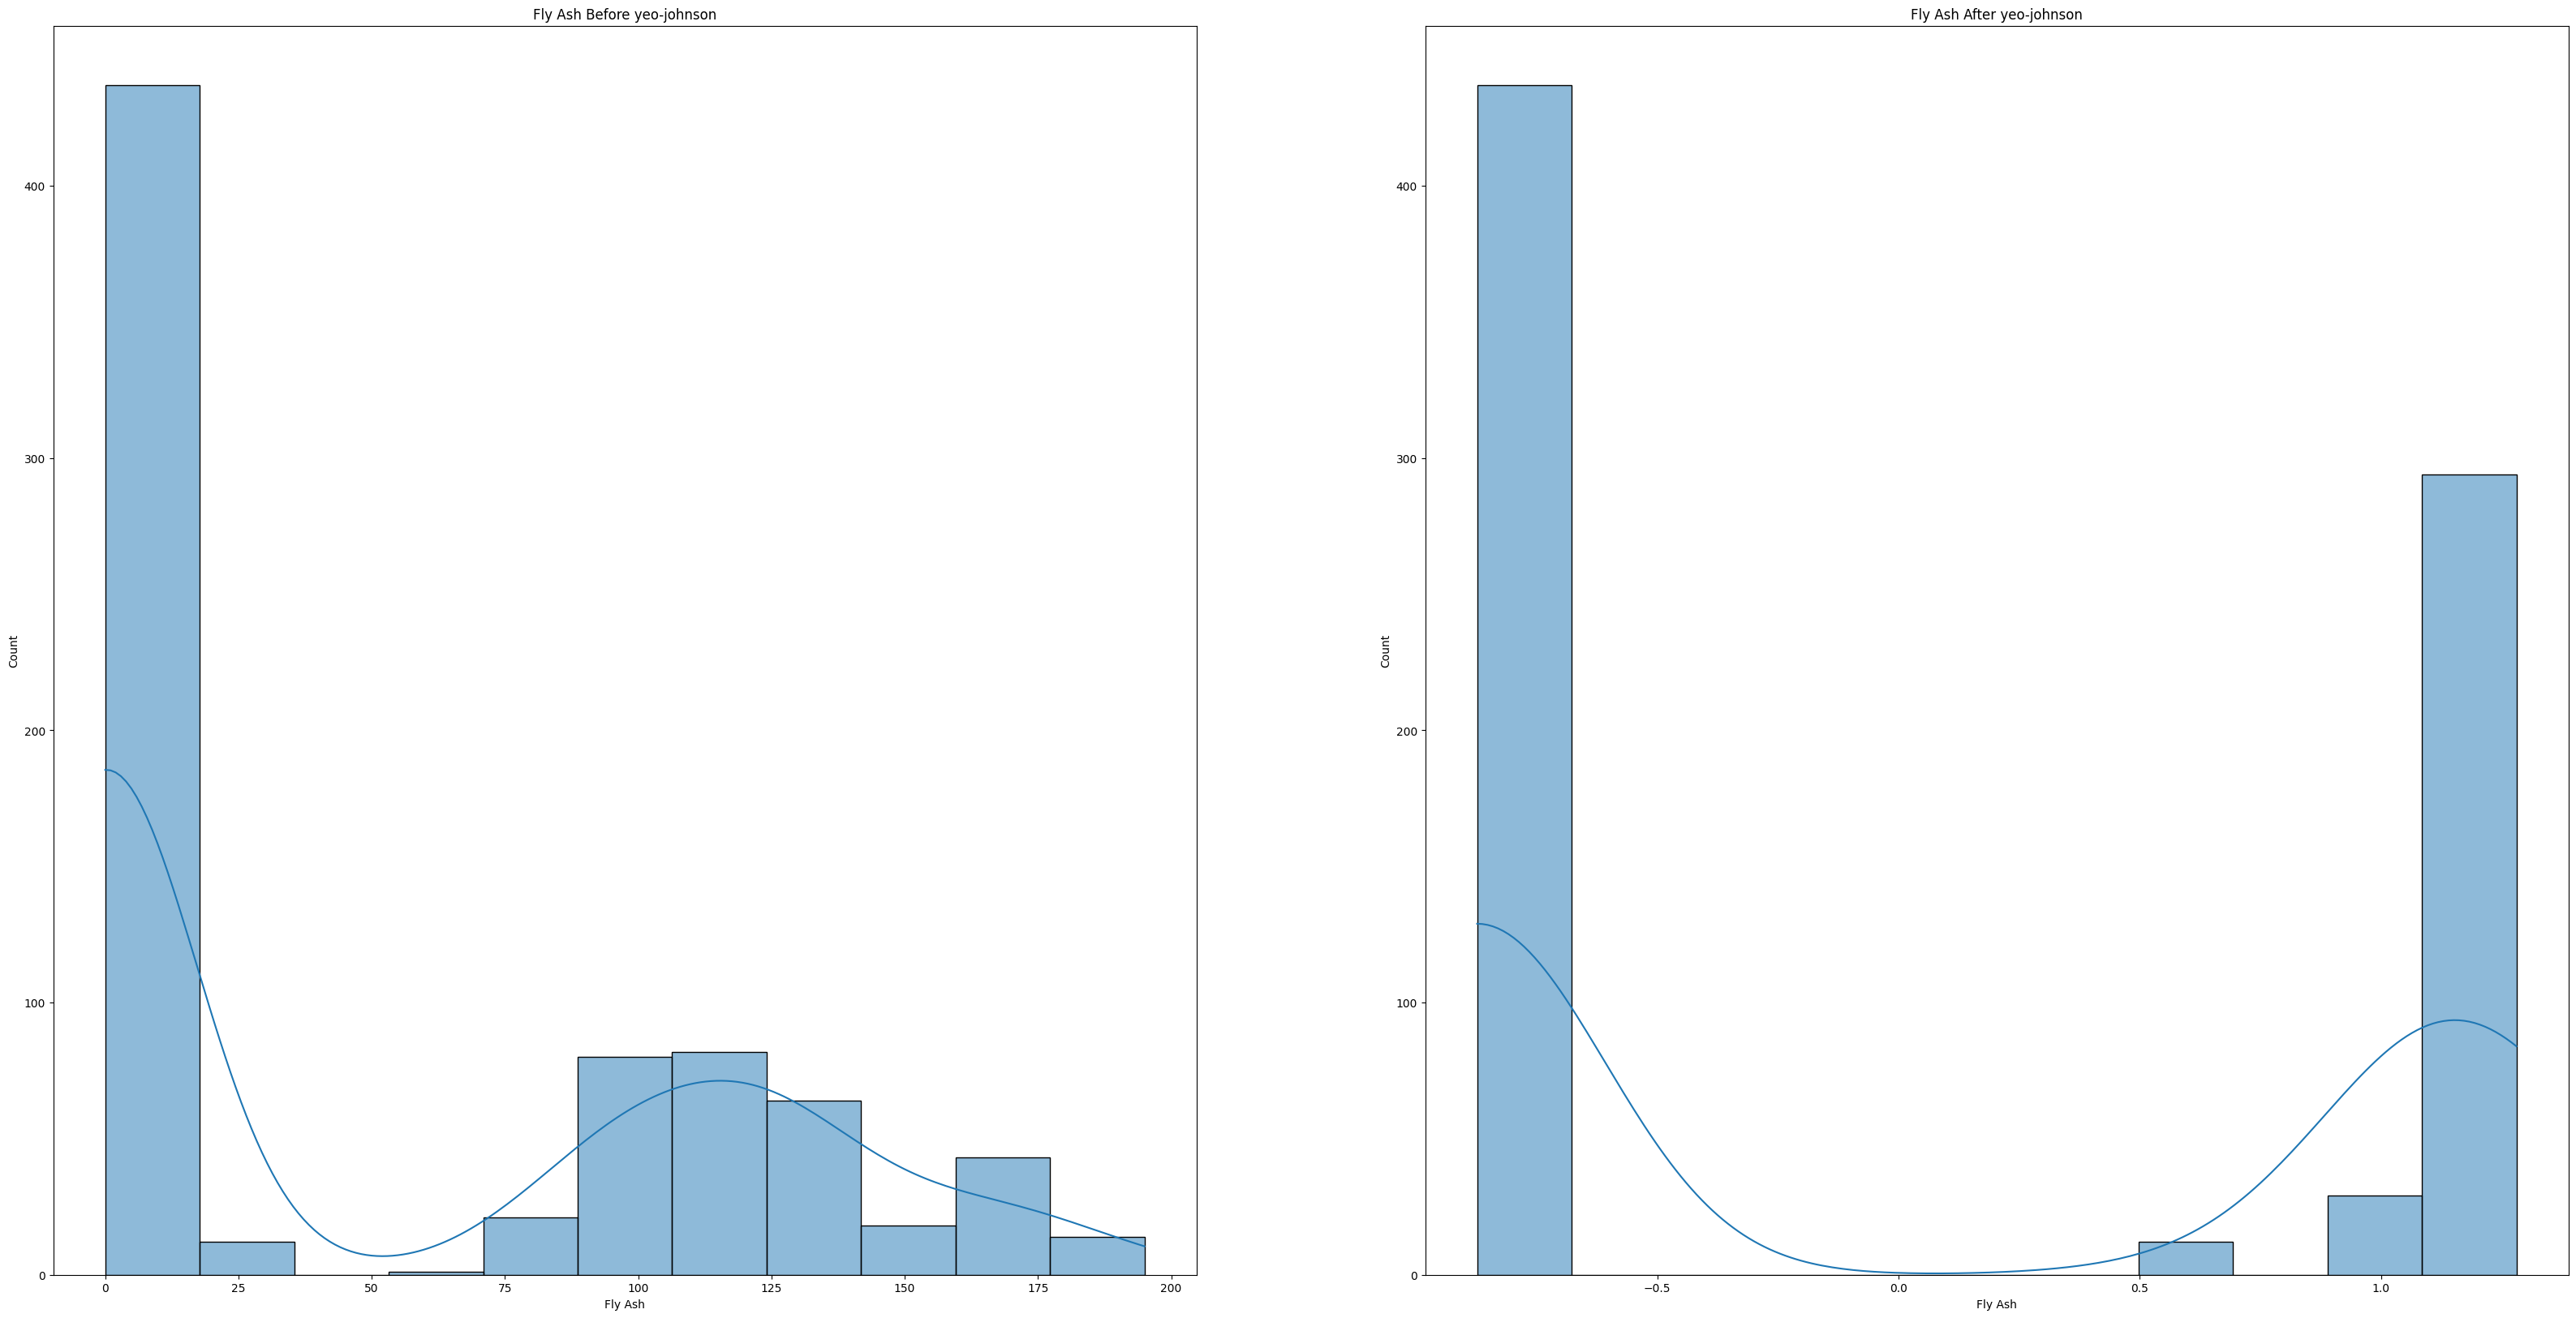

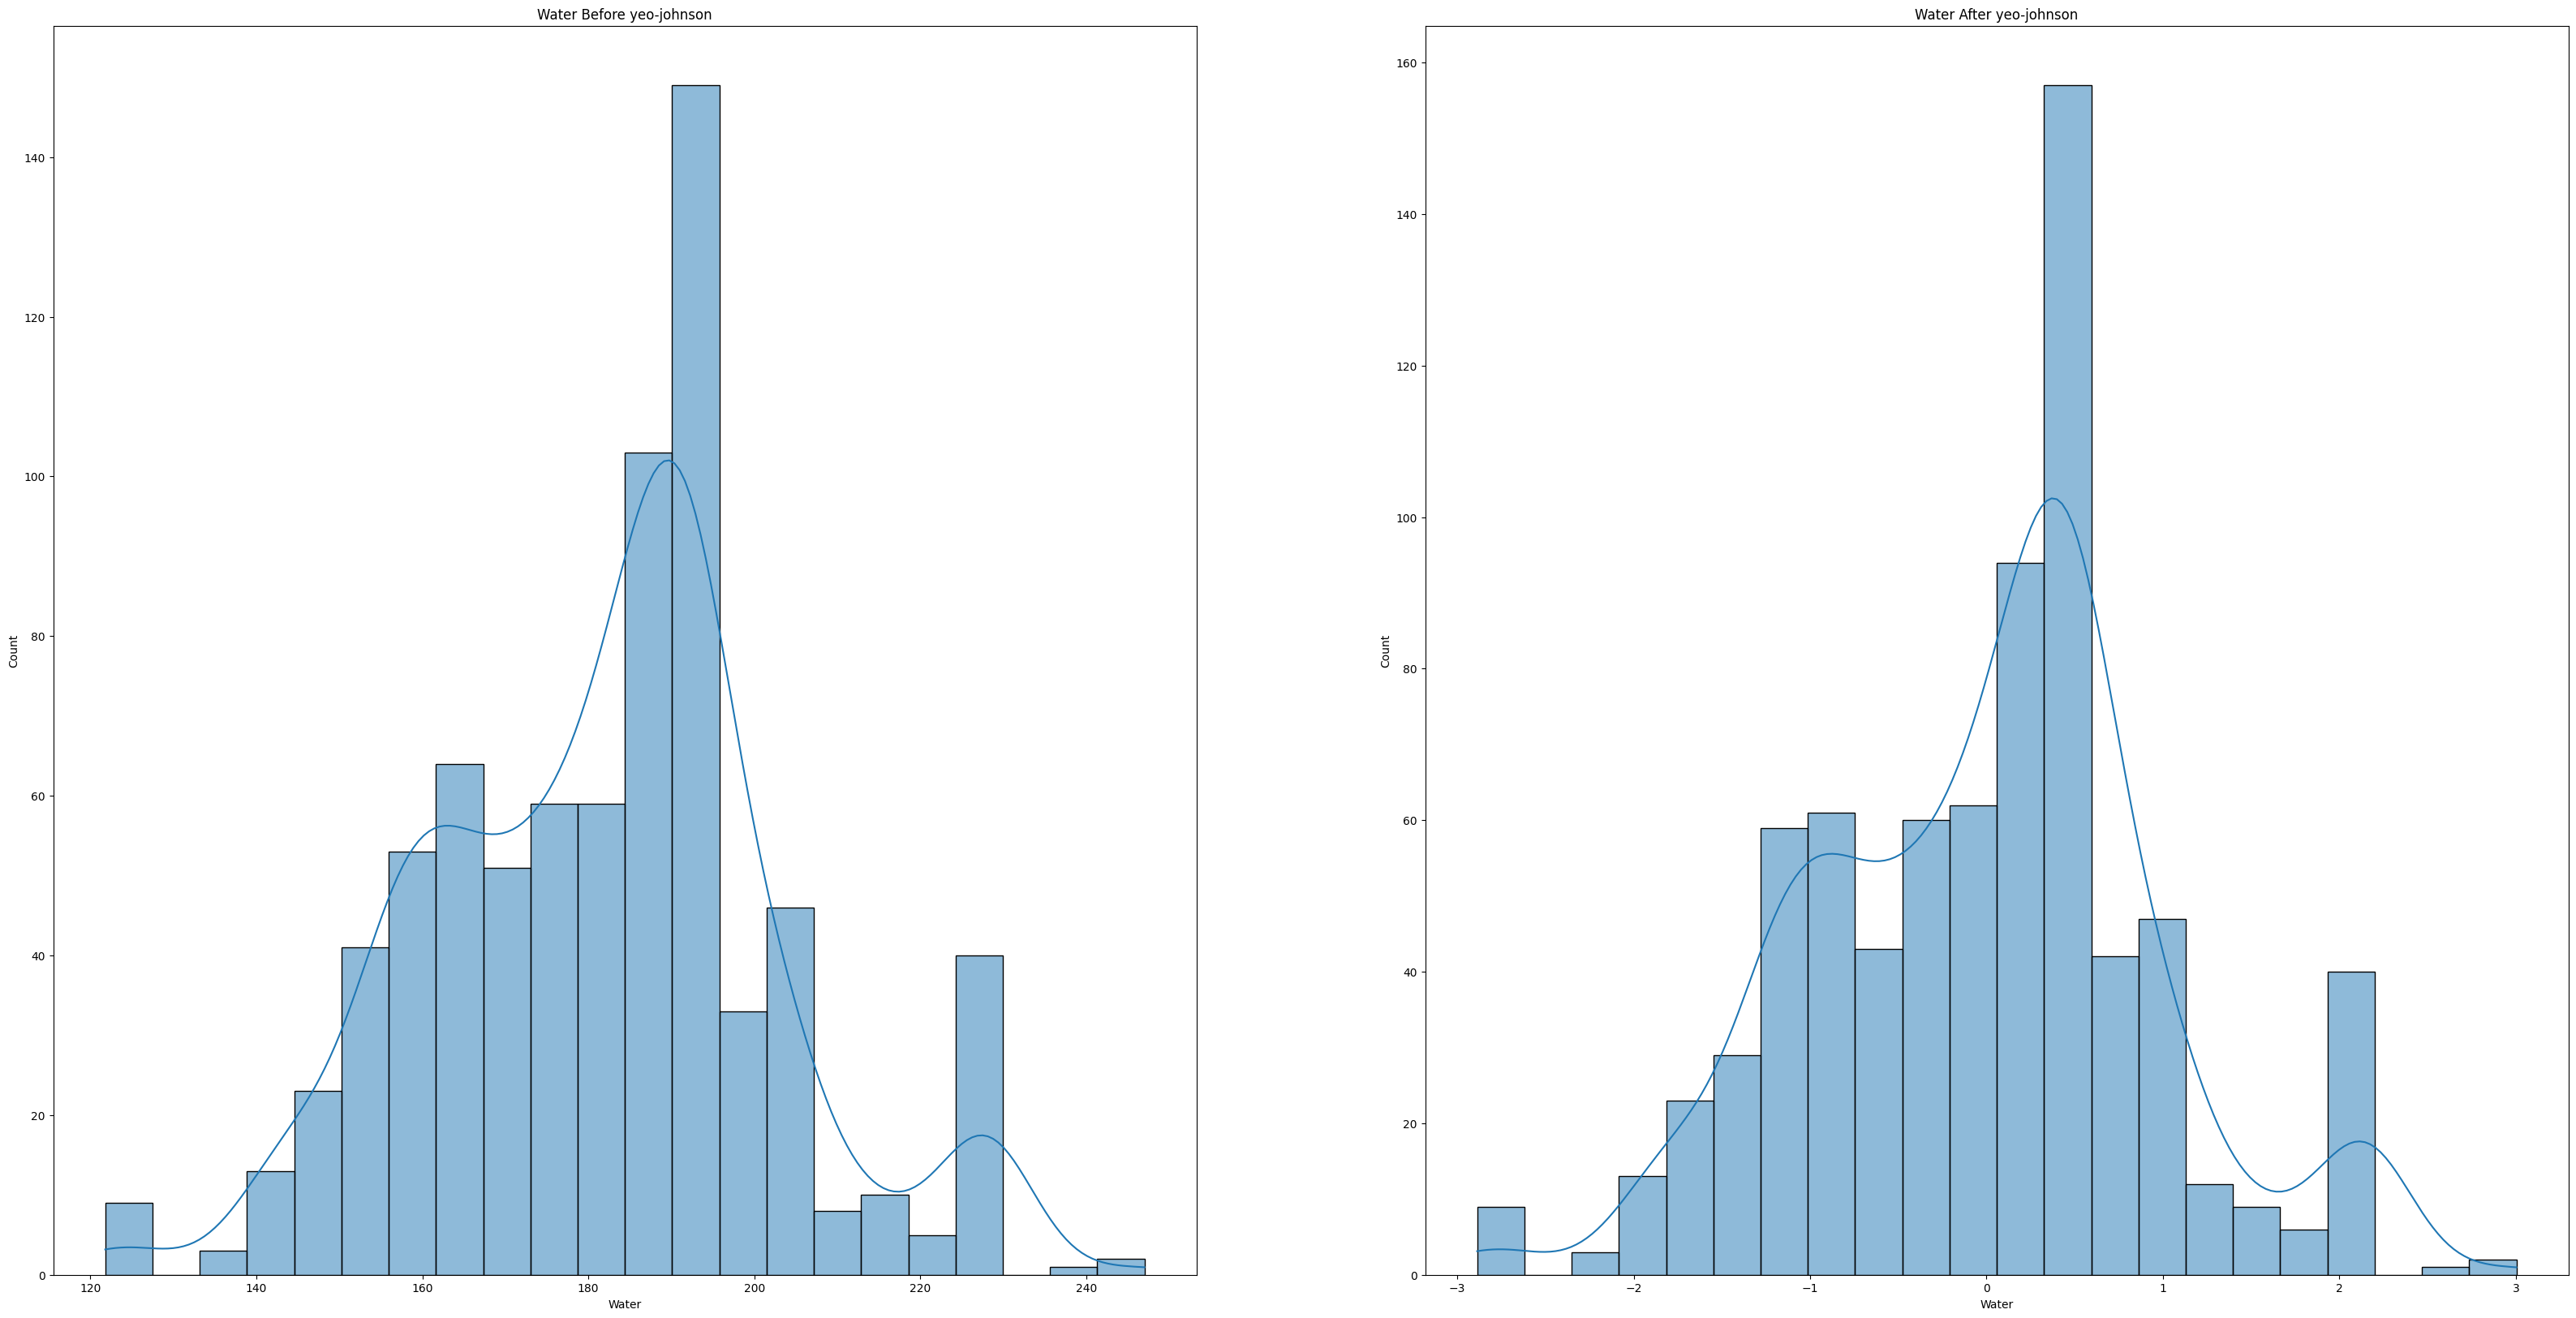

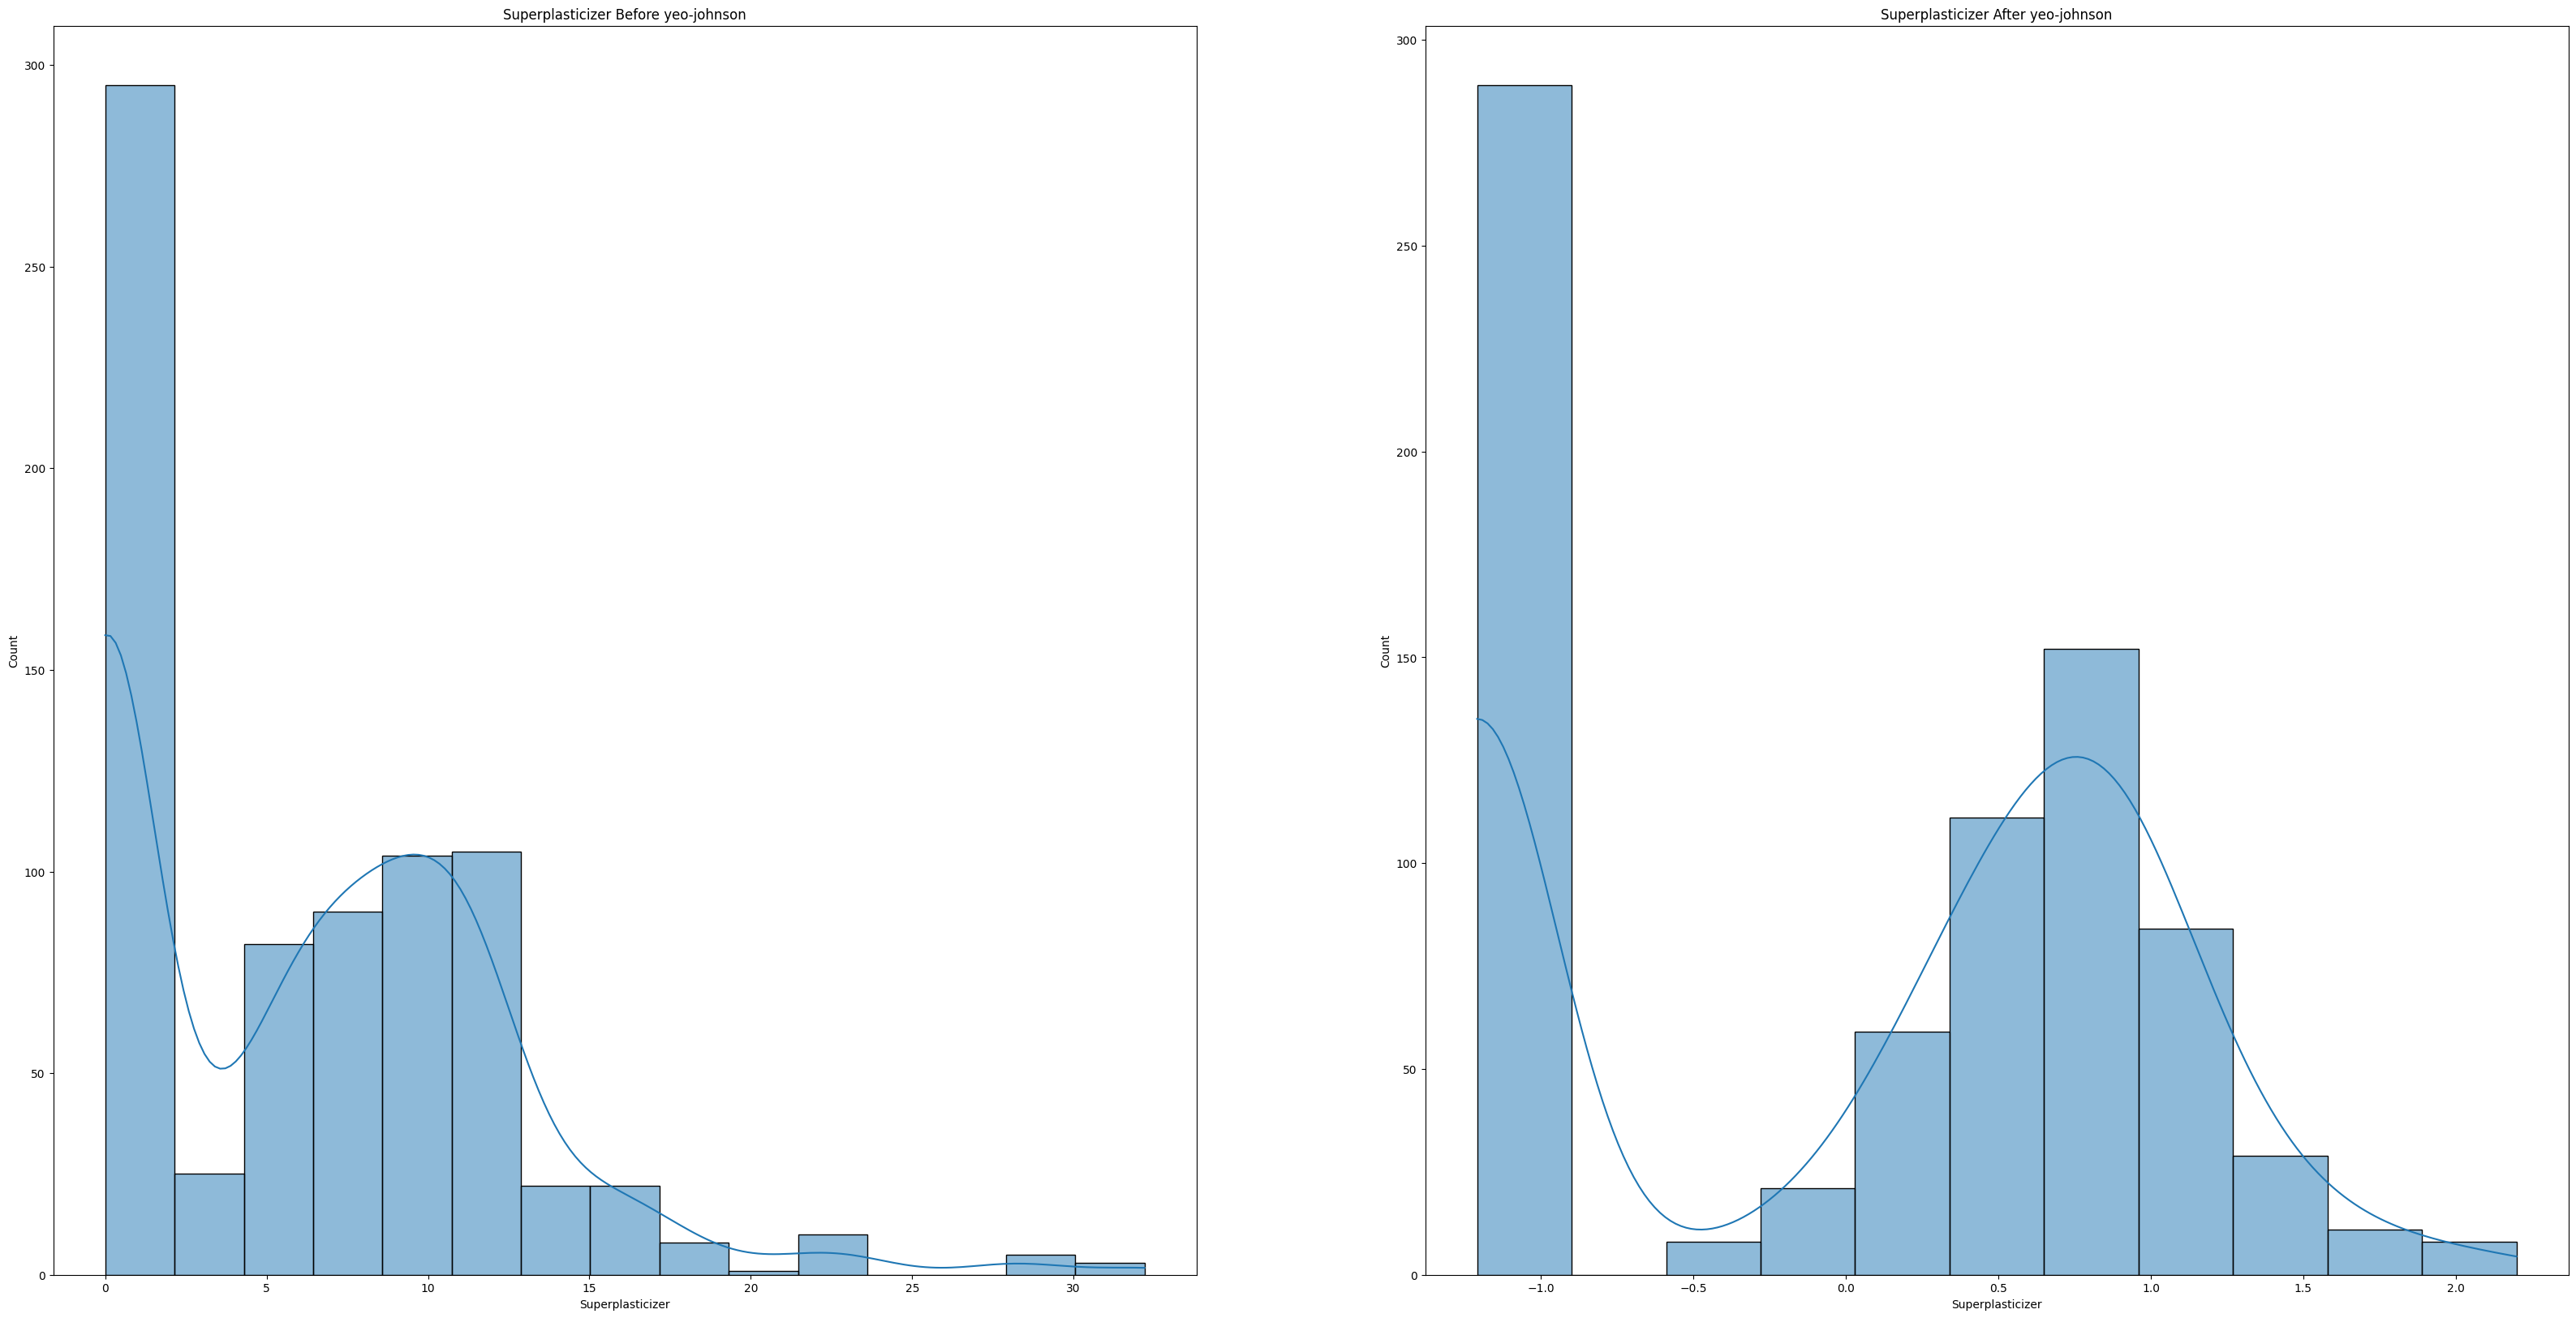

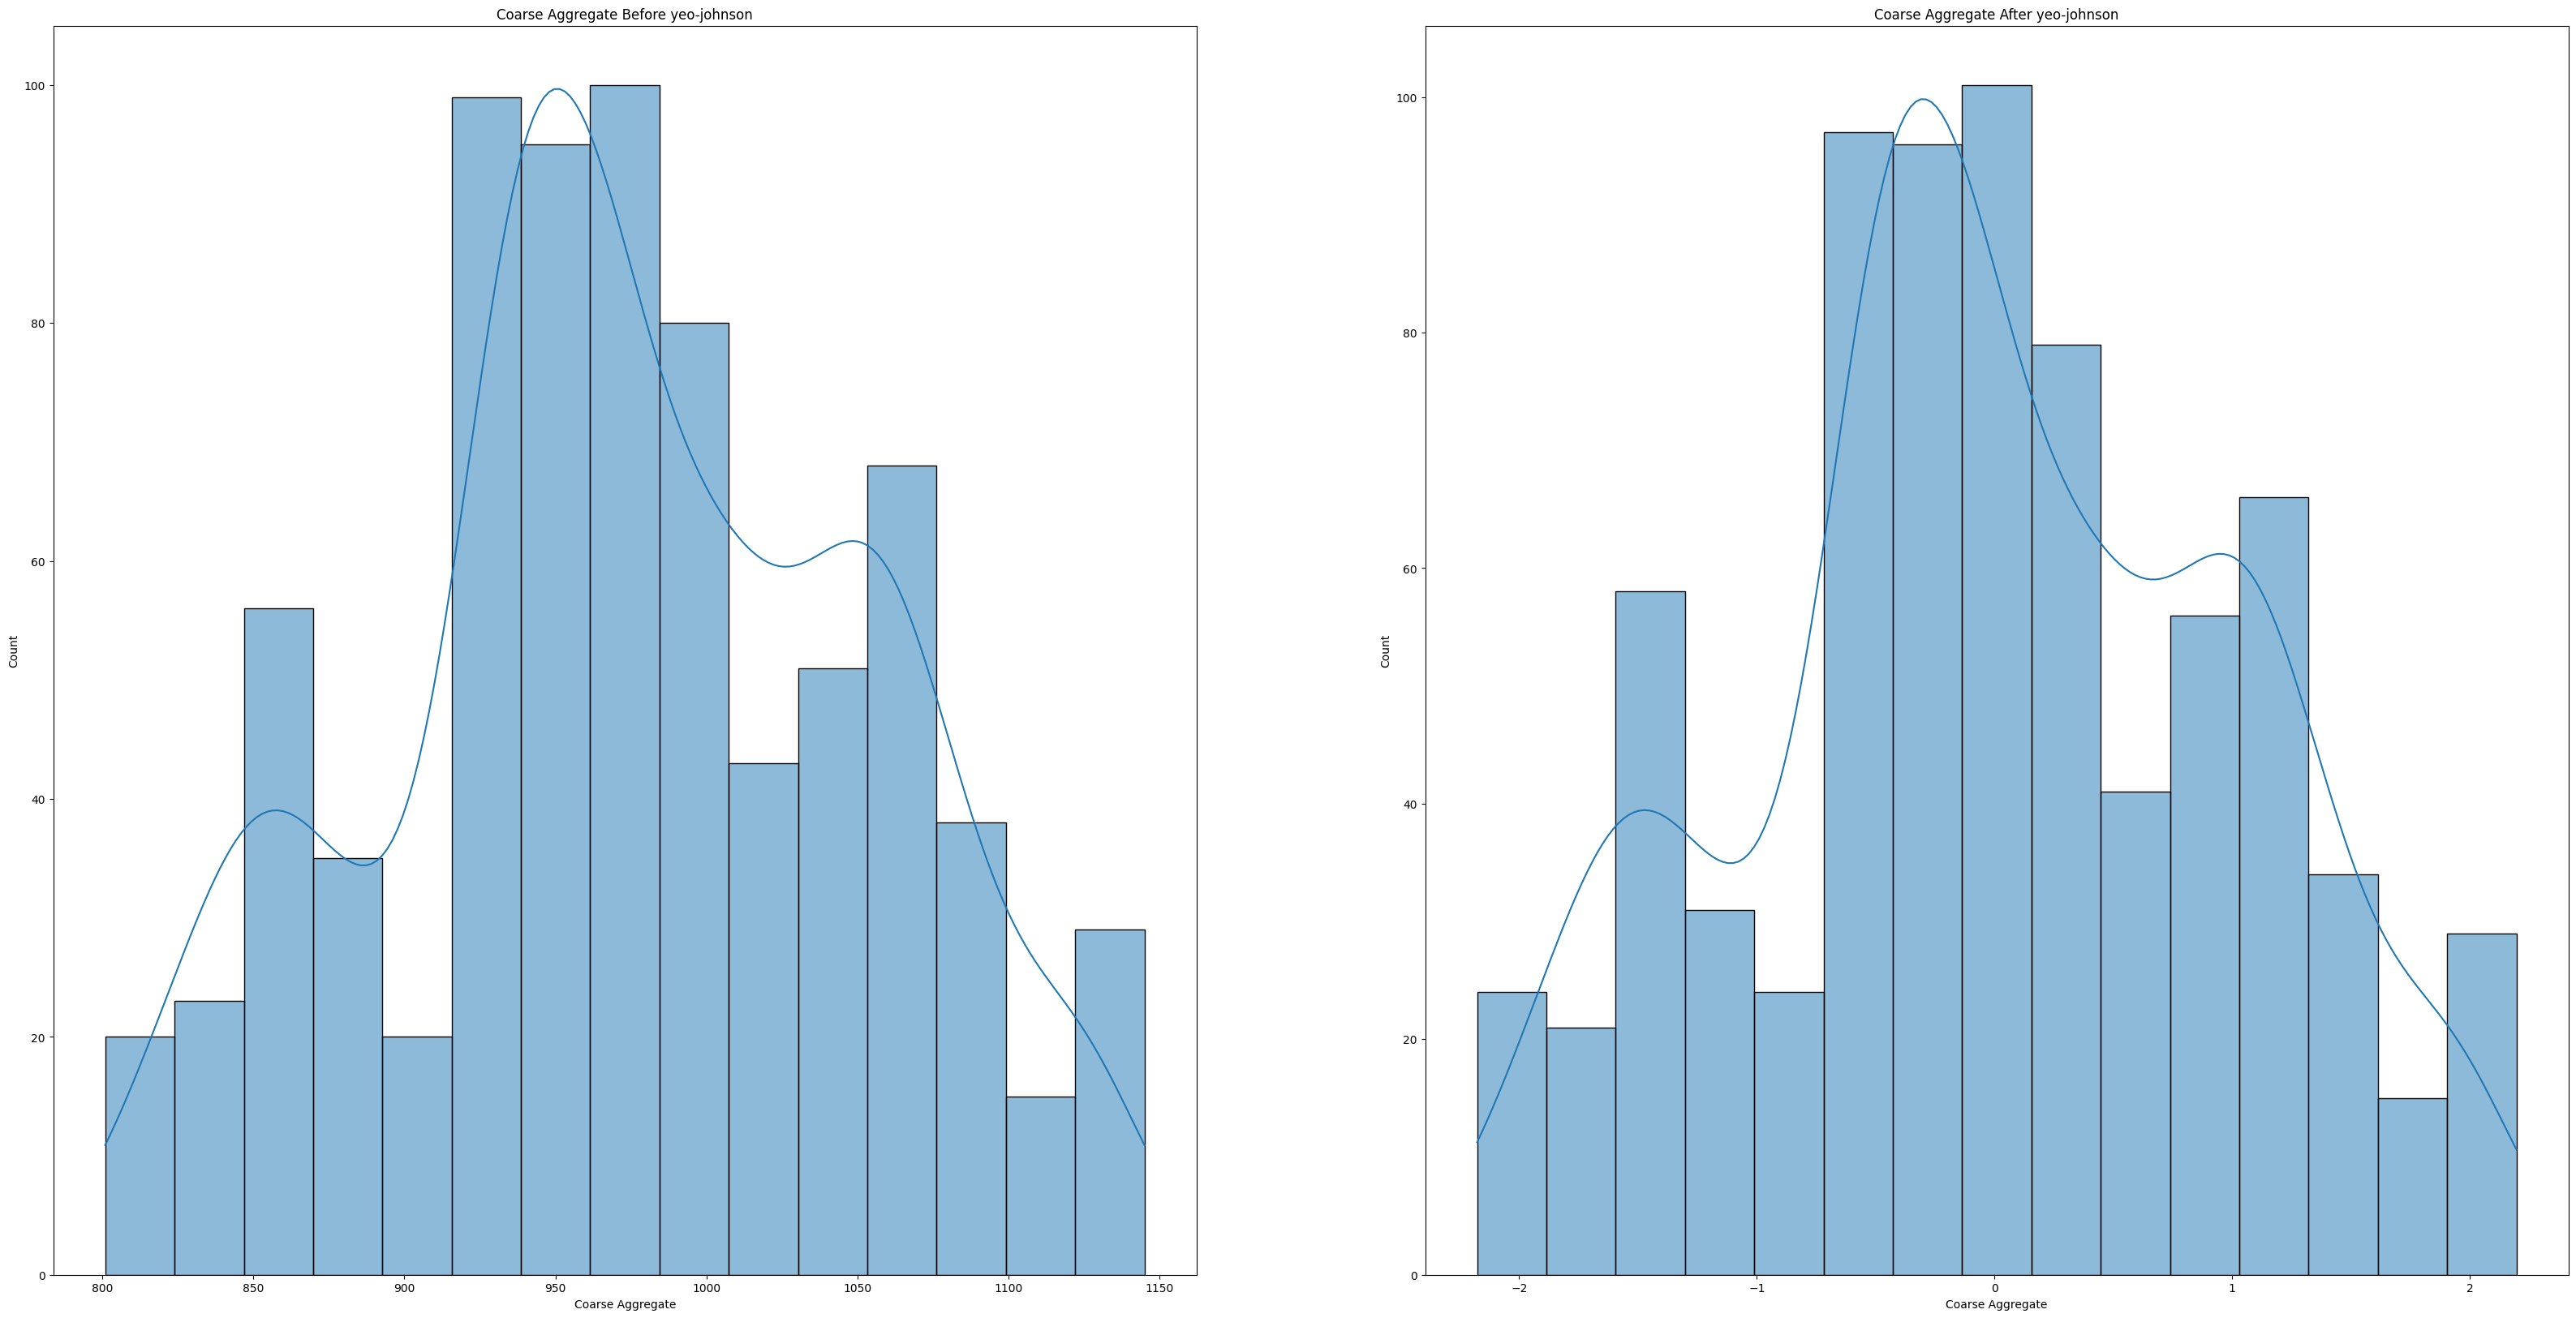

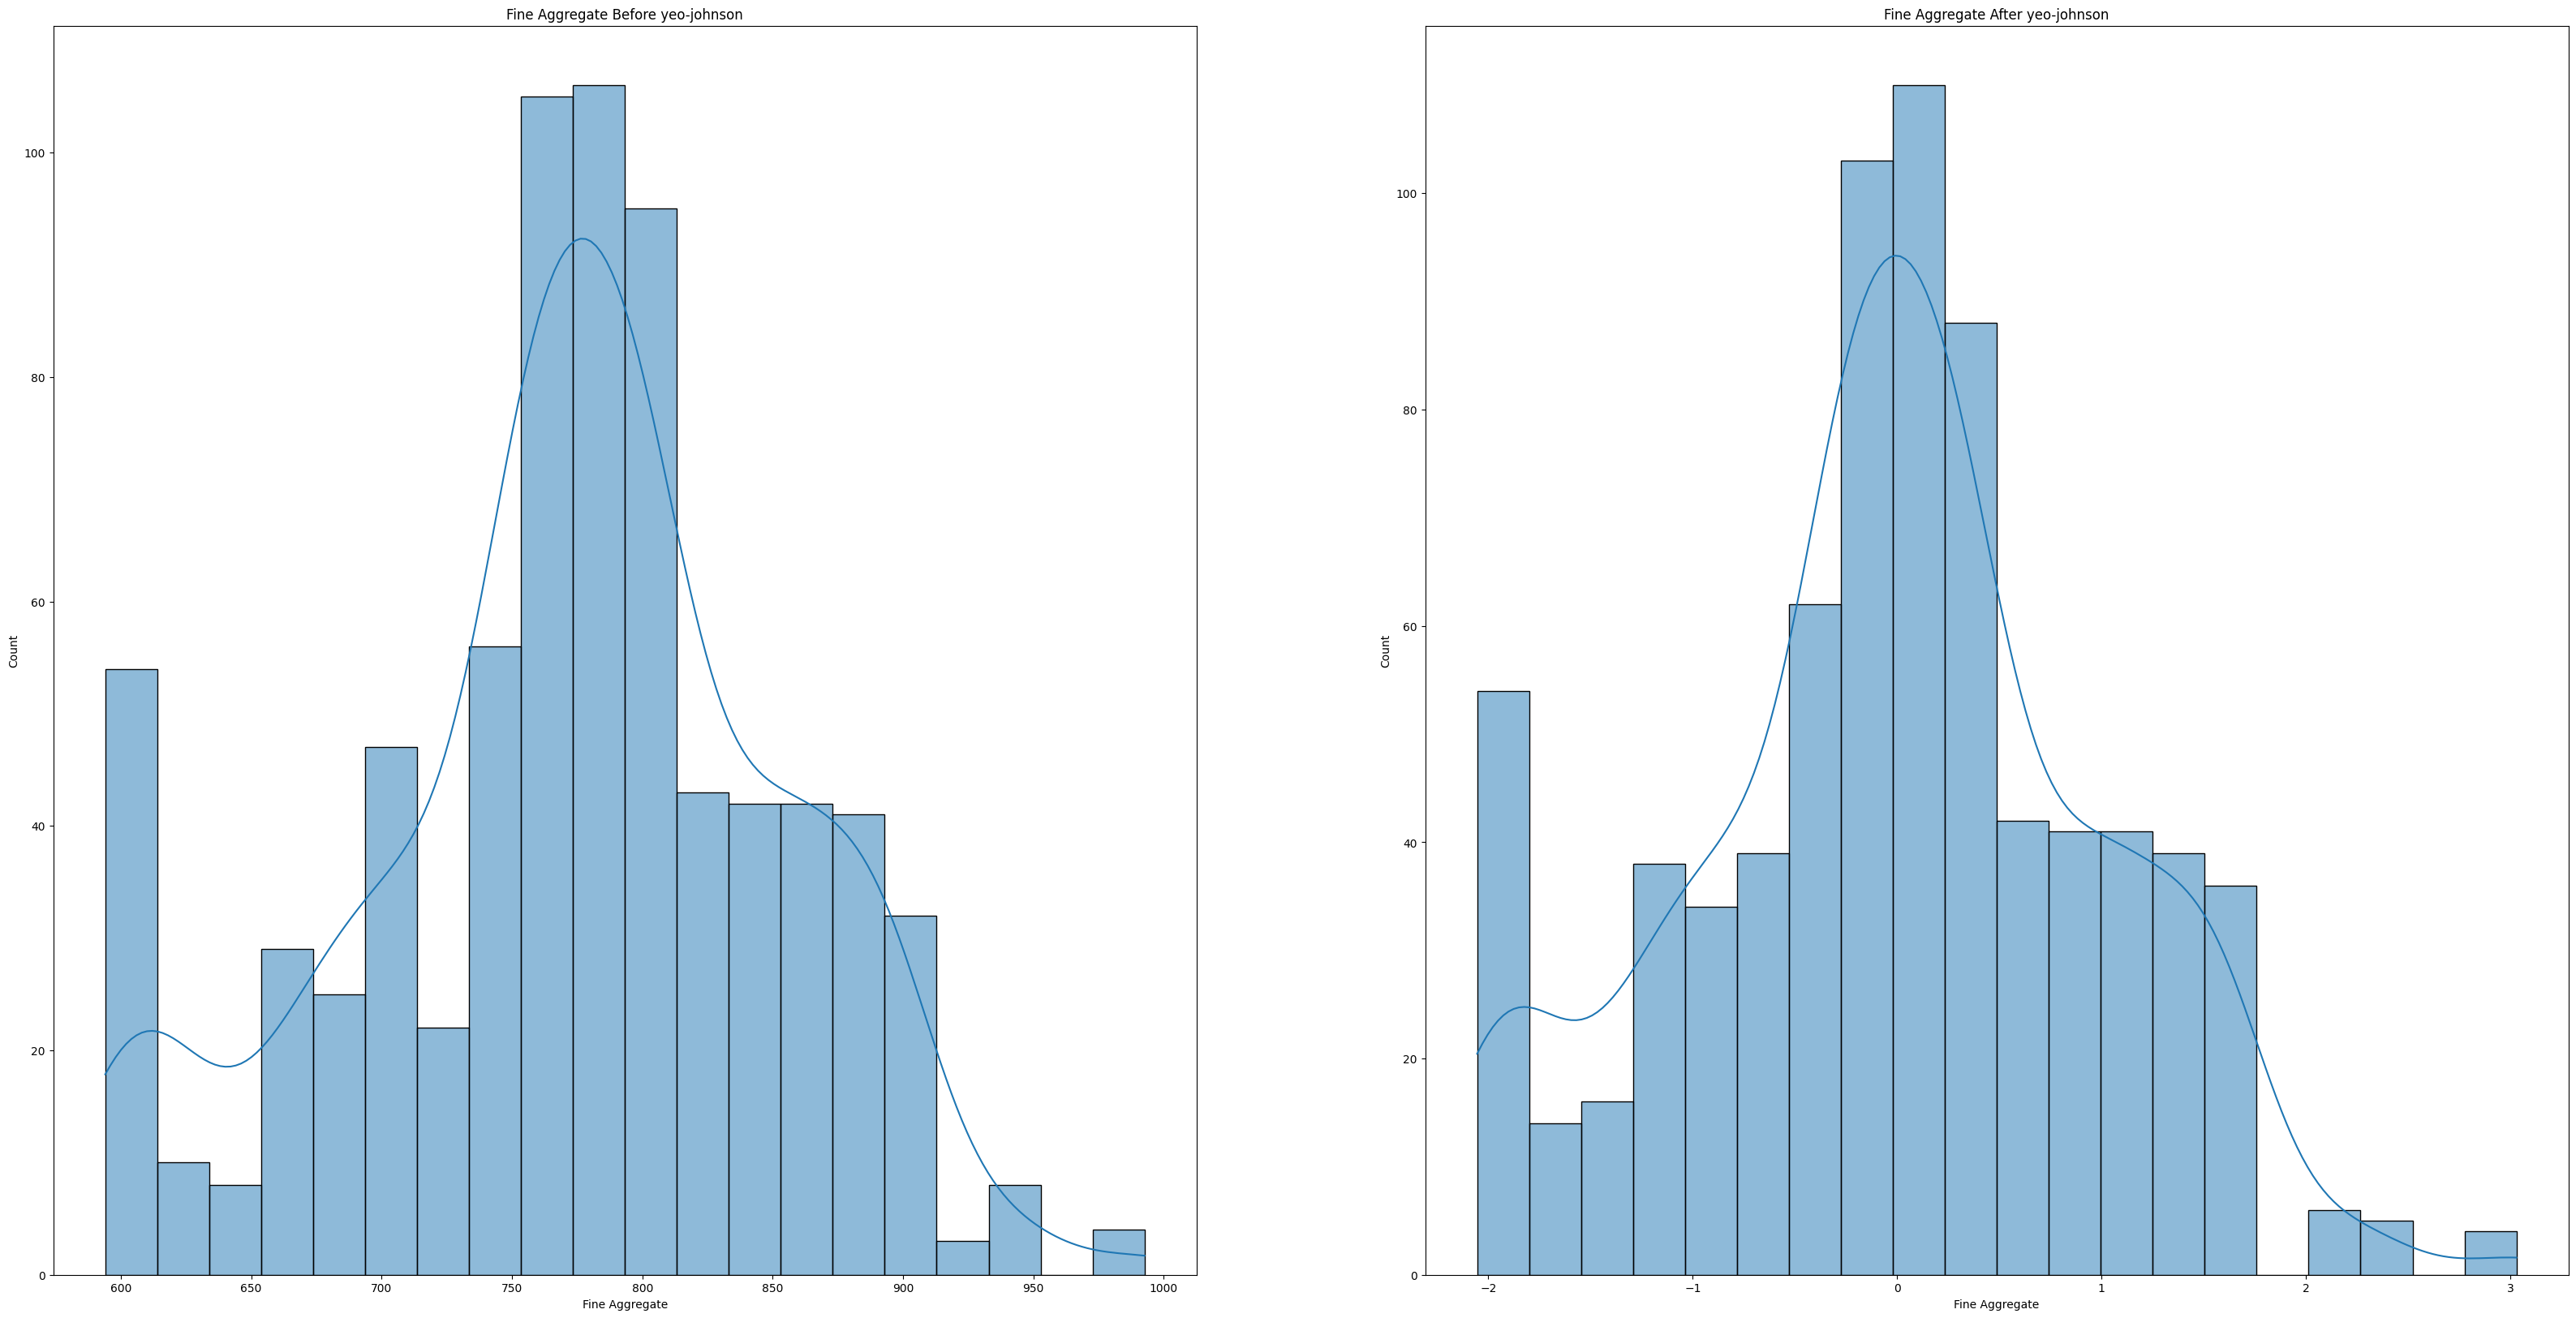

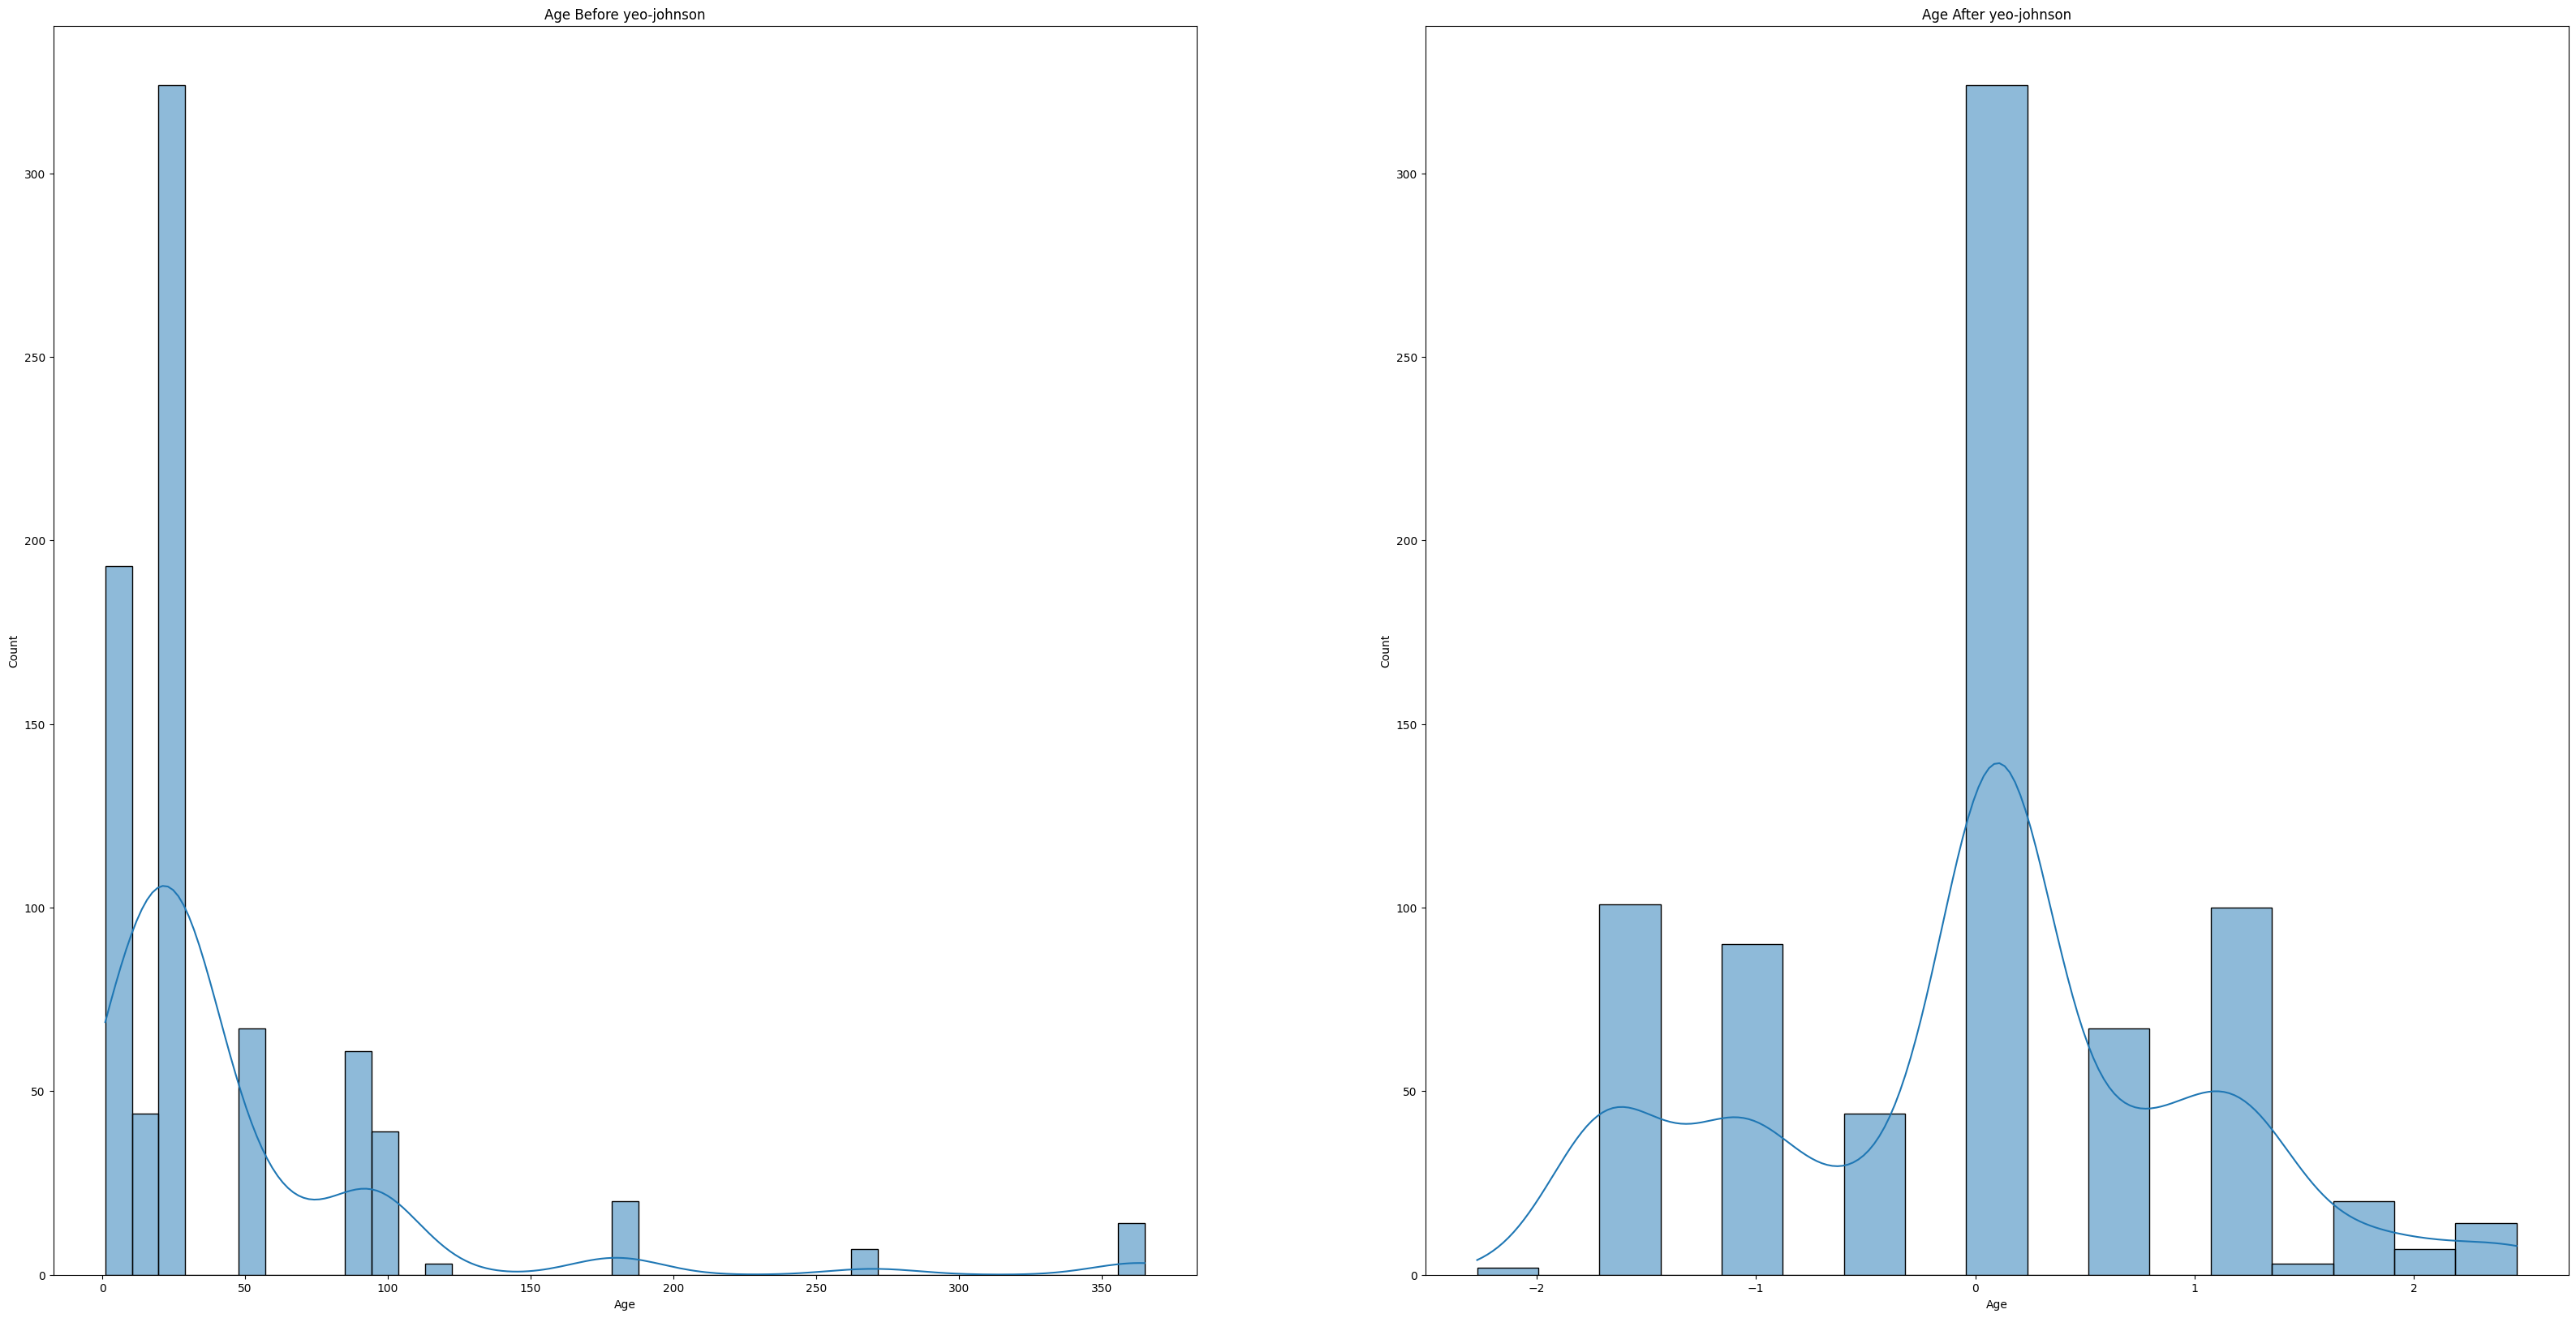

Test R2: 0.8075413185978144
CV R2: 0.6736522482908133


In [104]:
transformer('yeo-johnson')

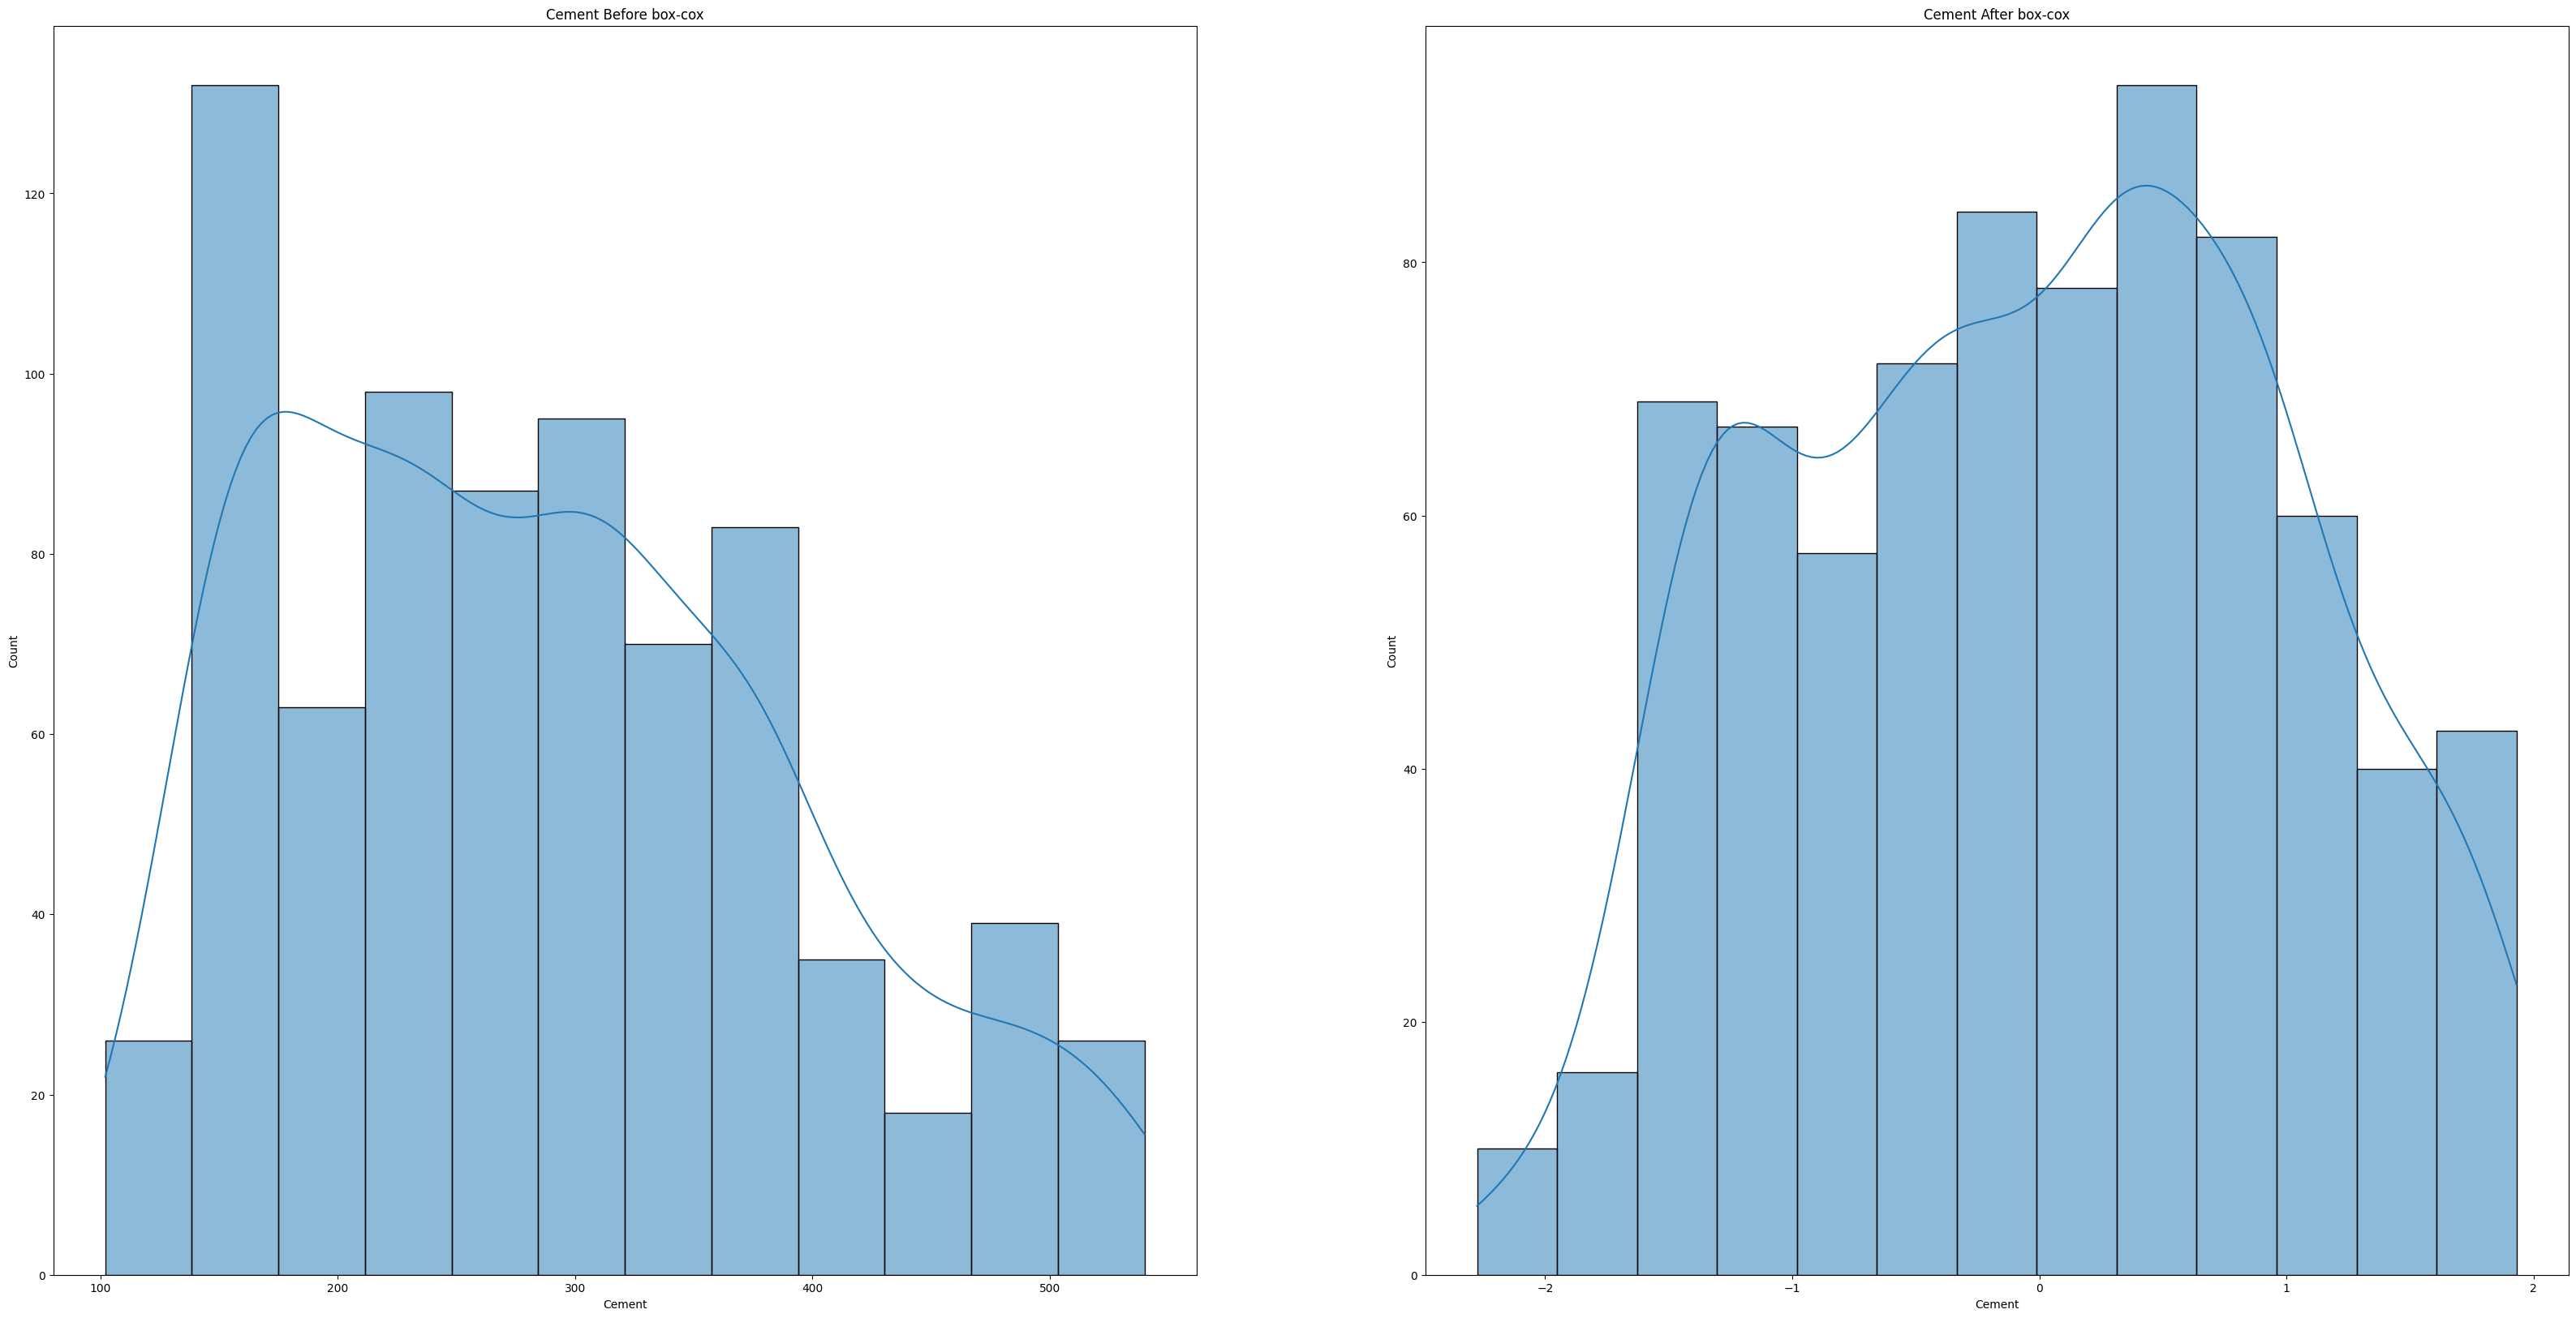

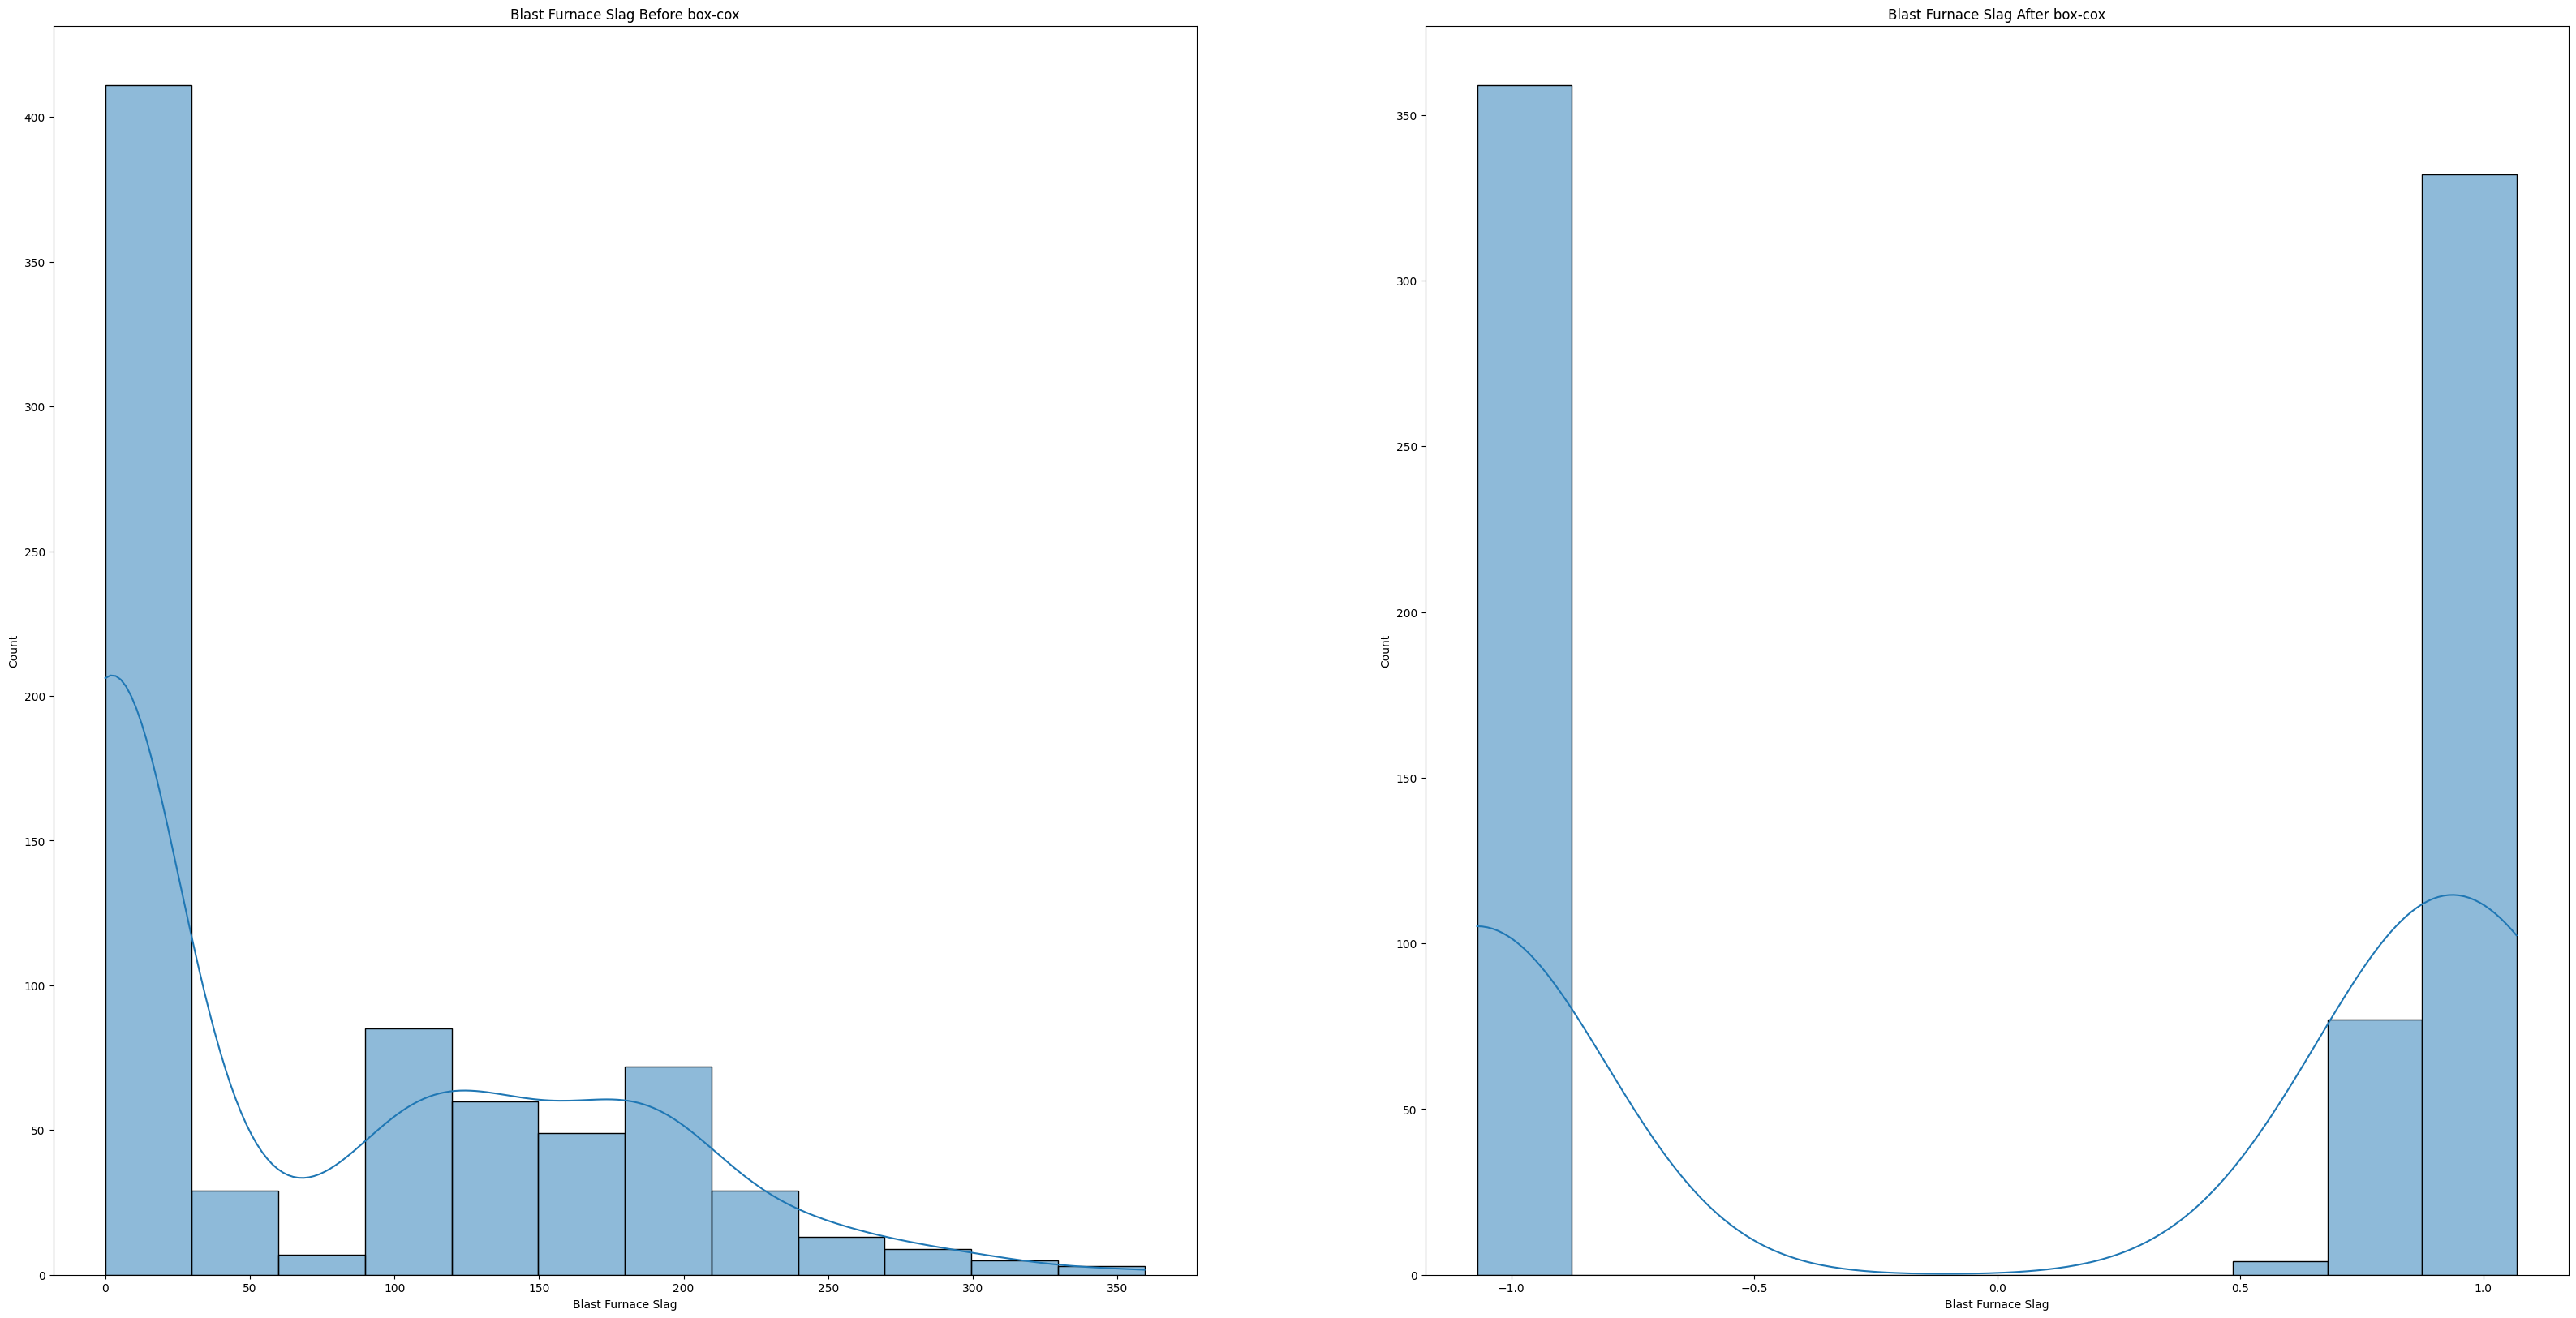

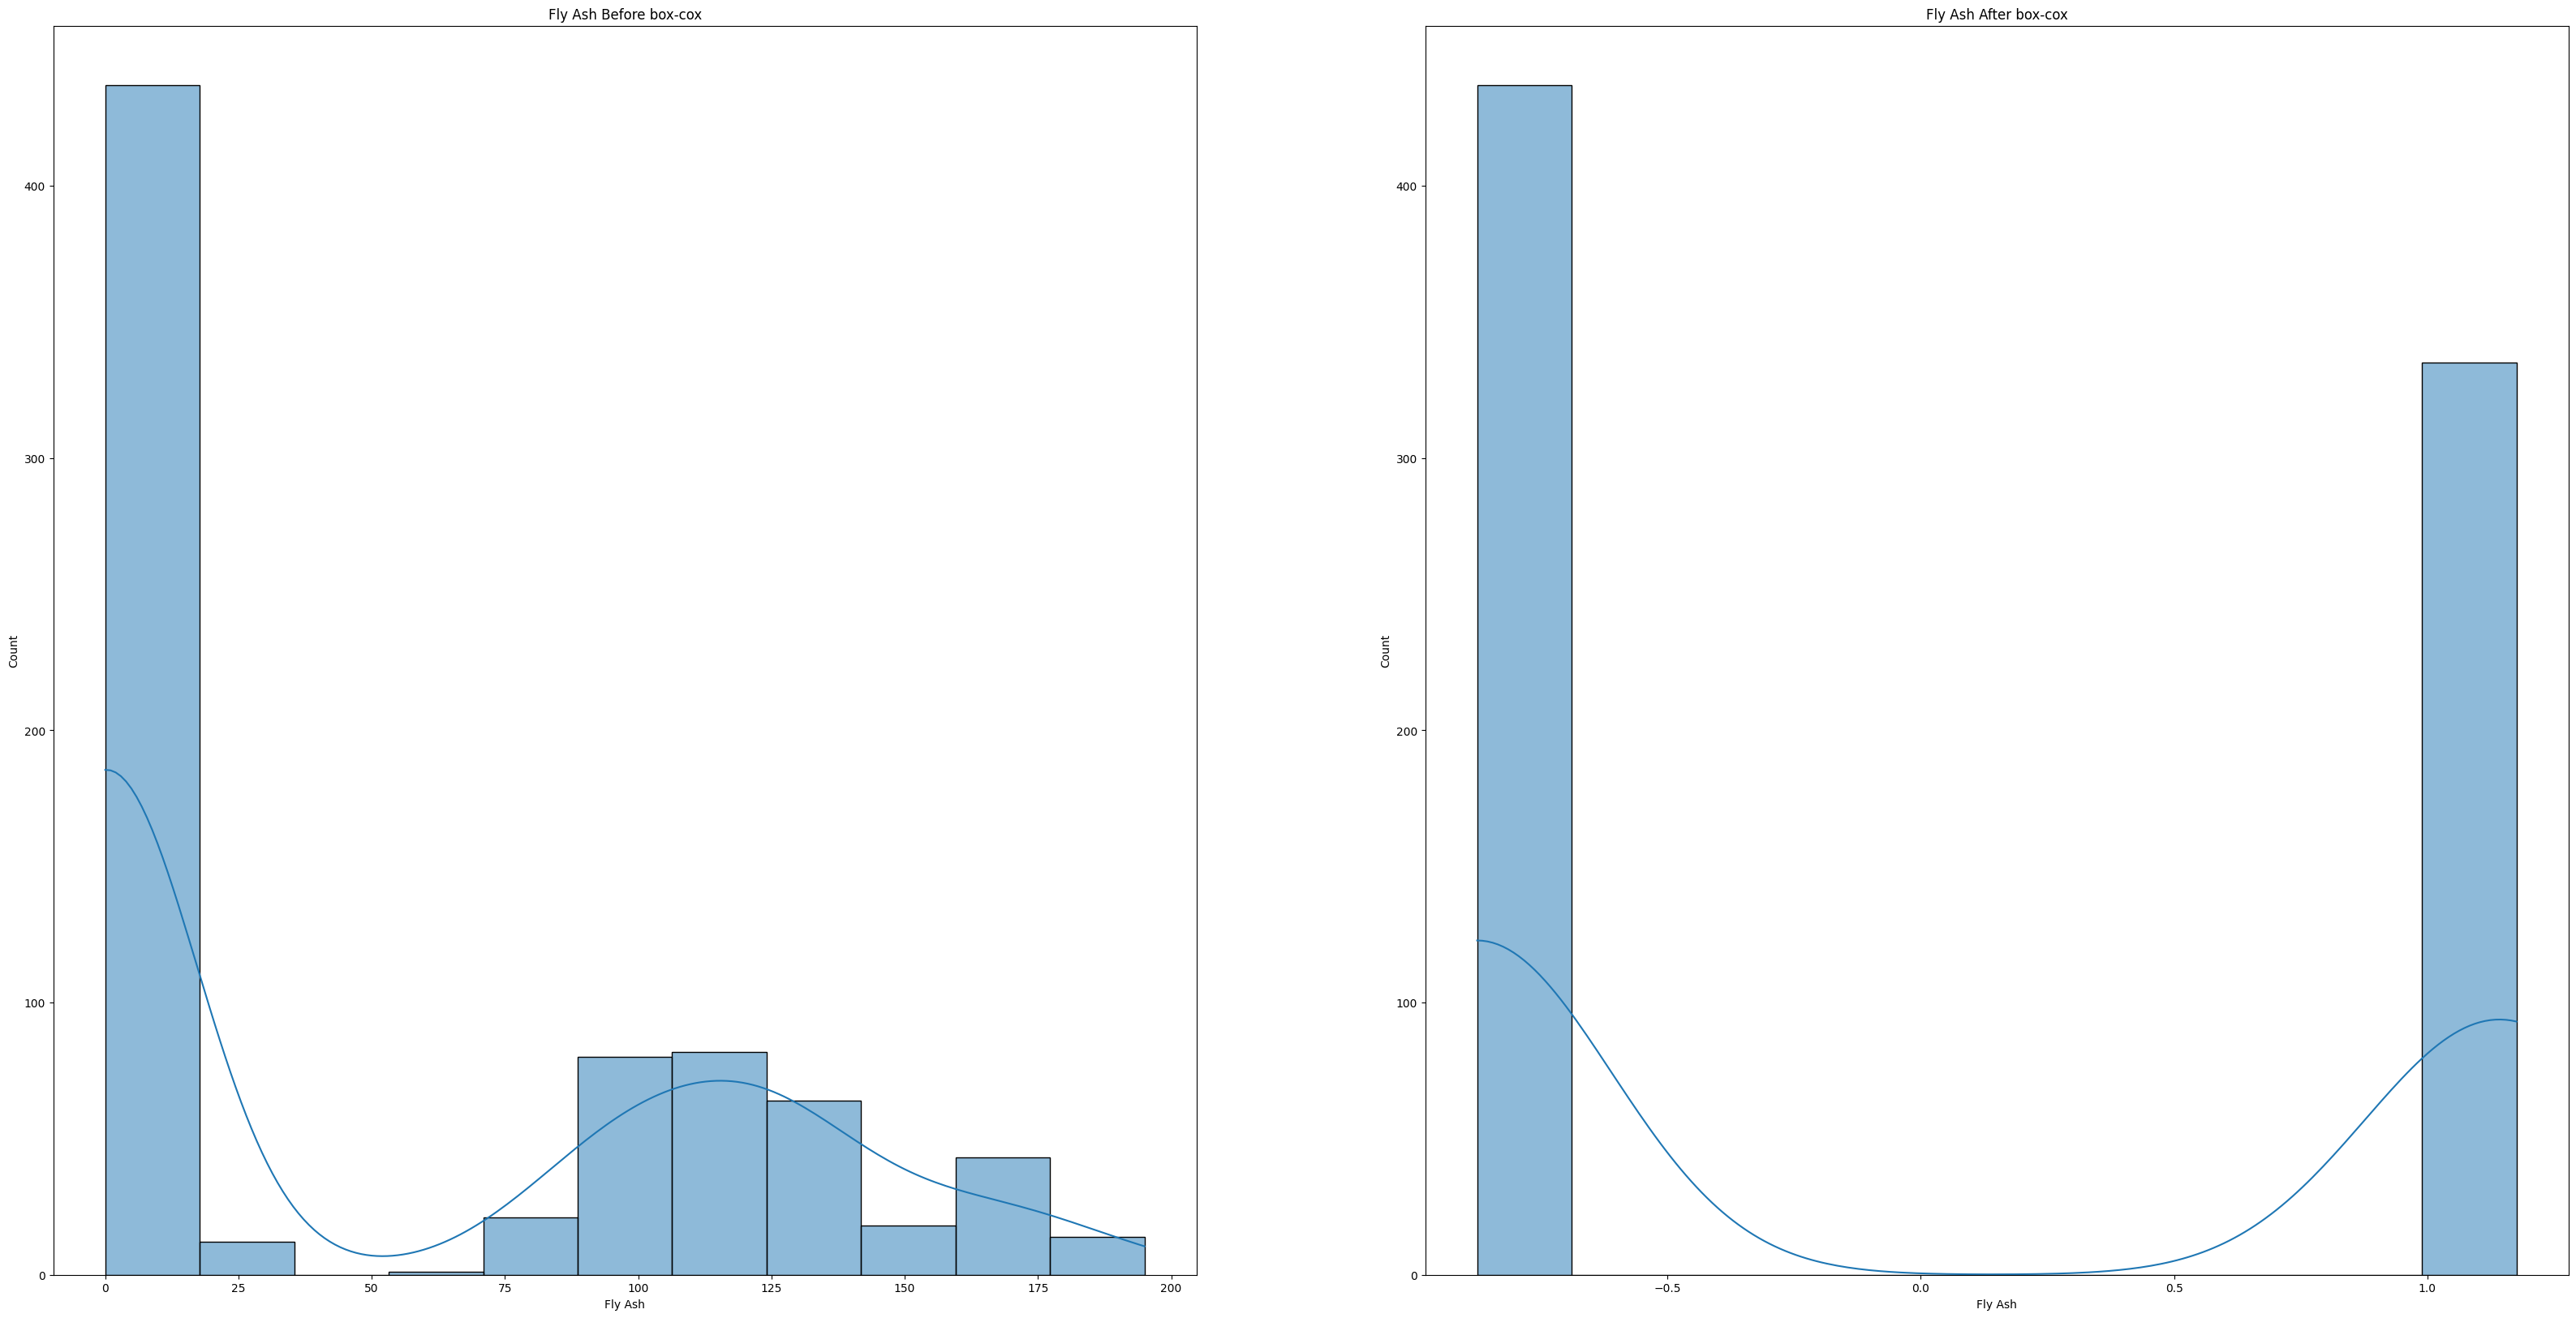

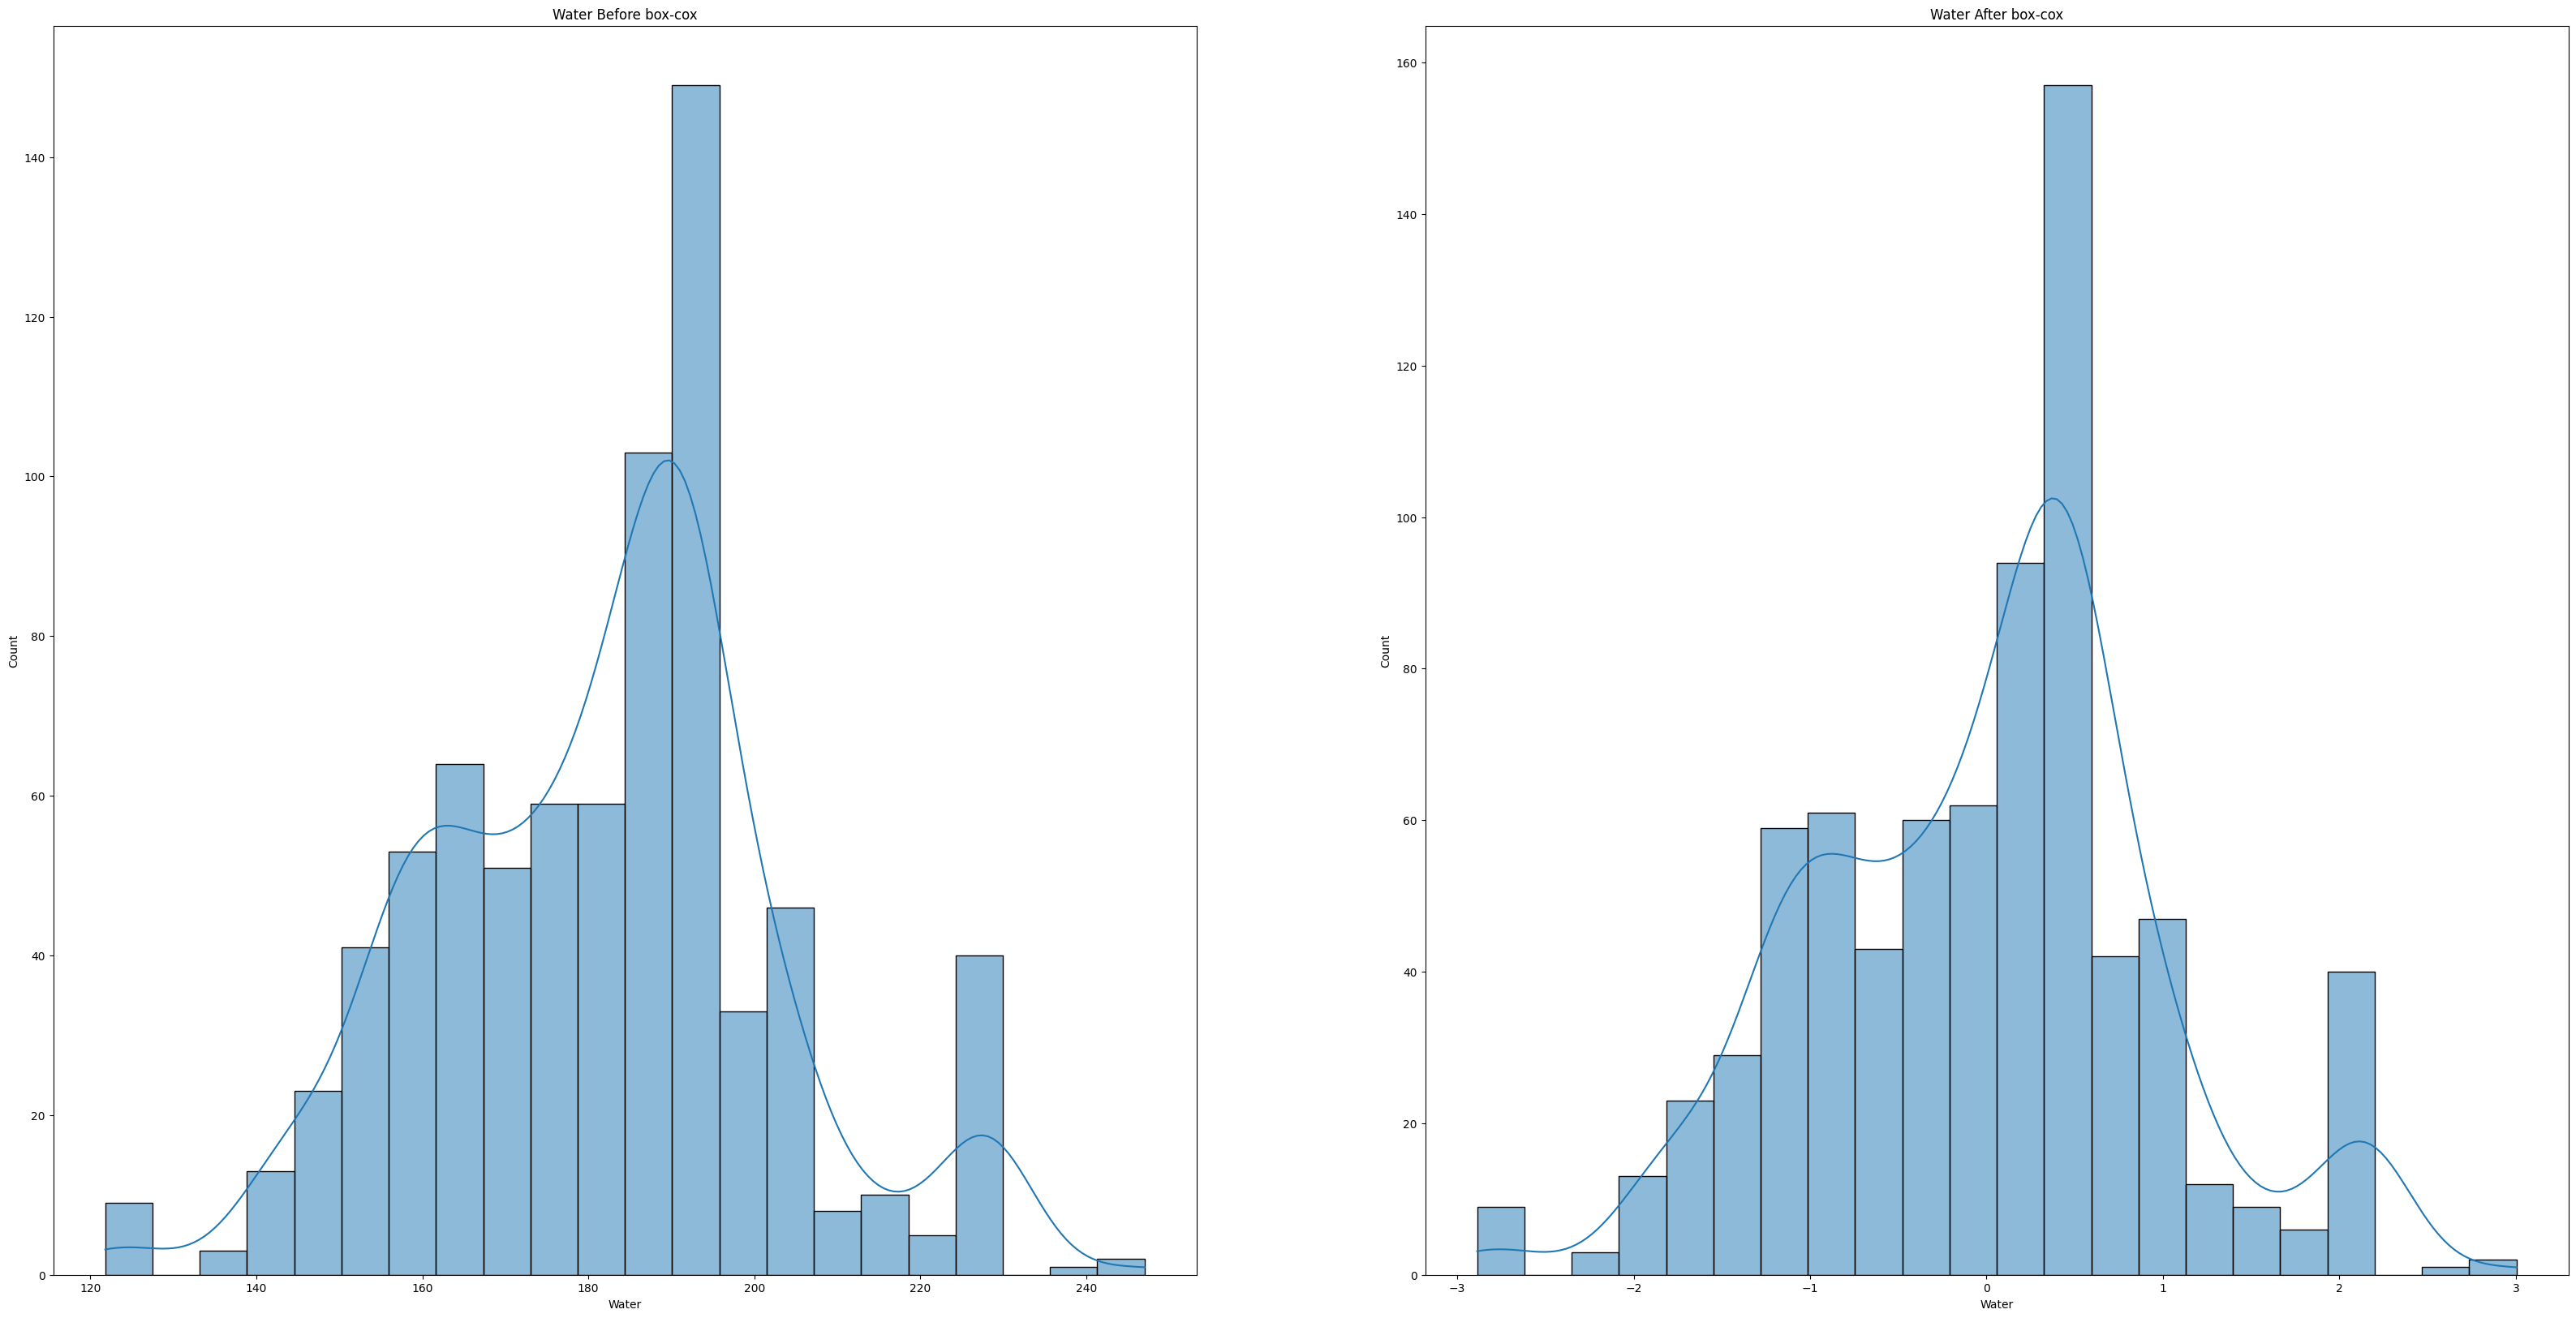

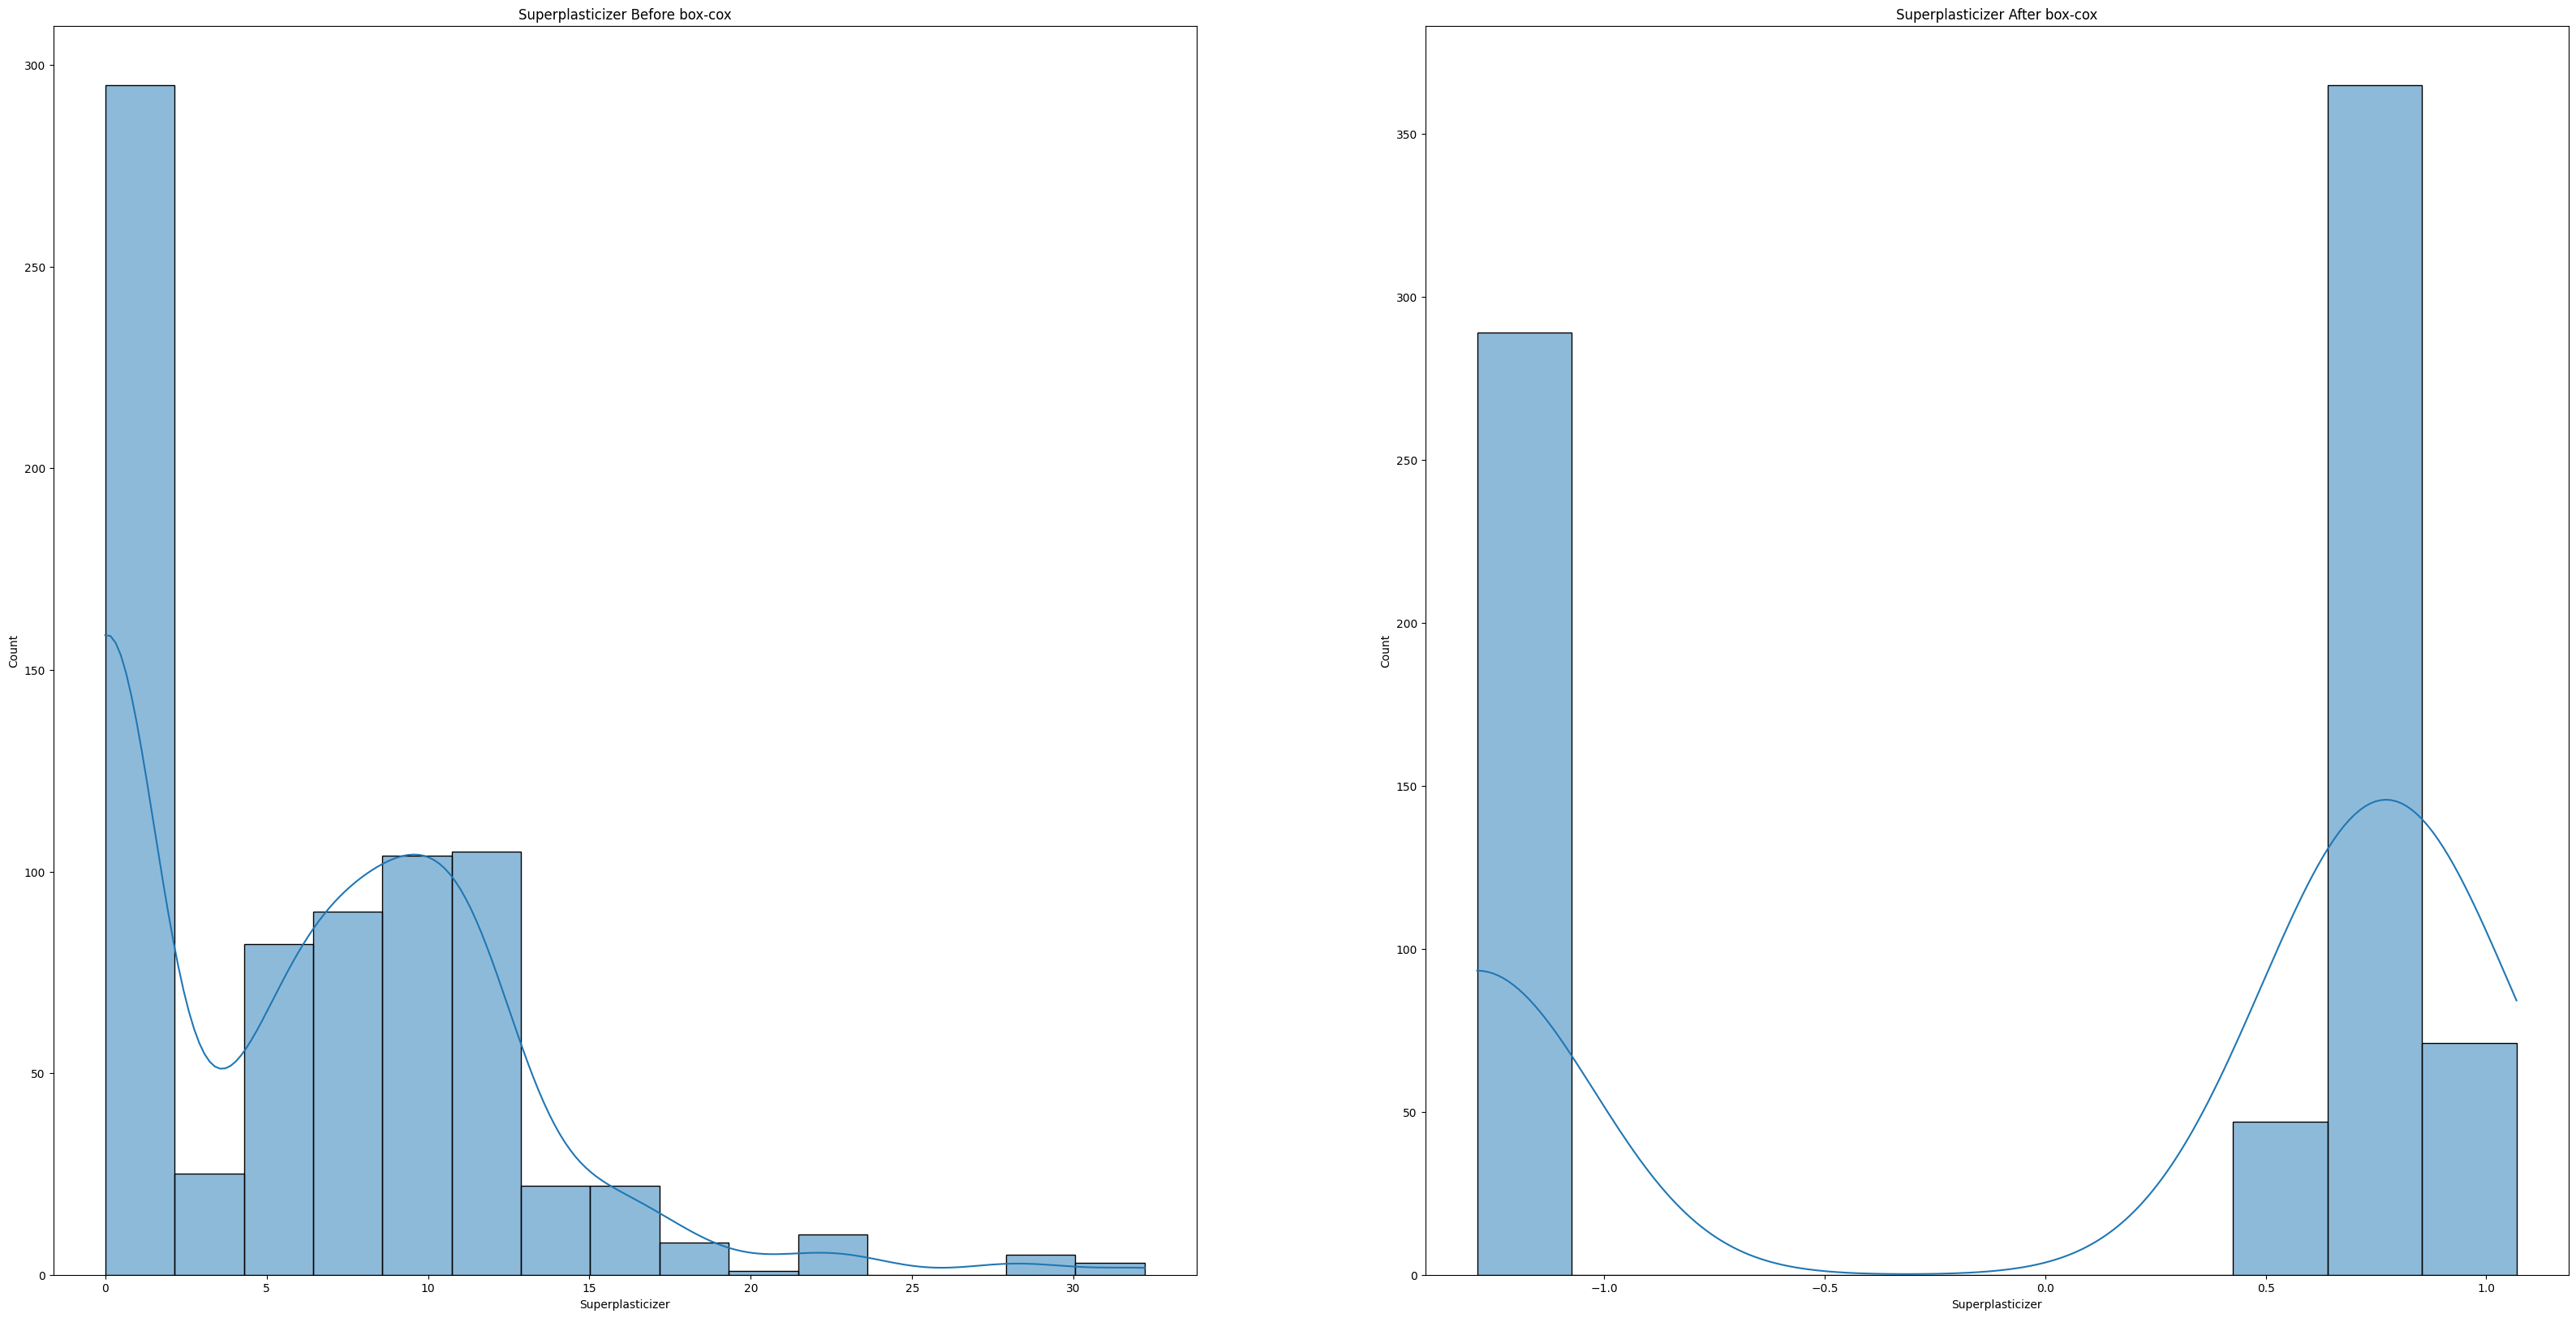

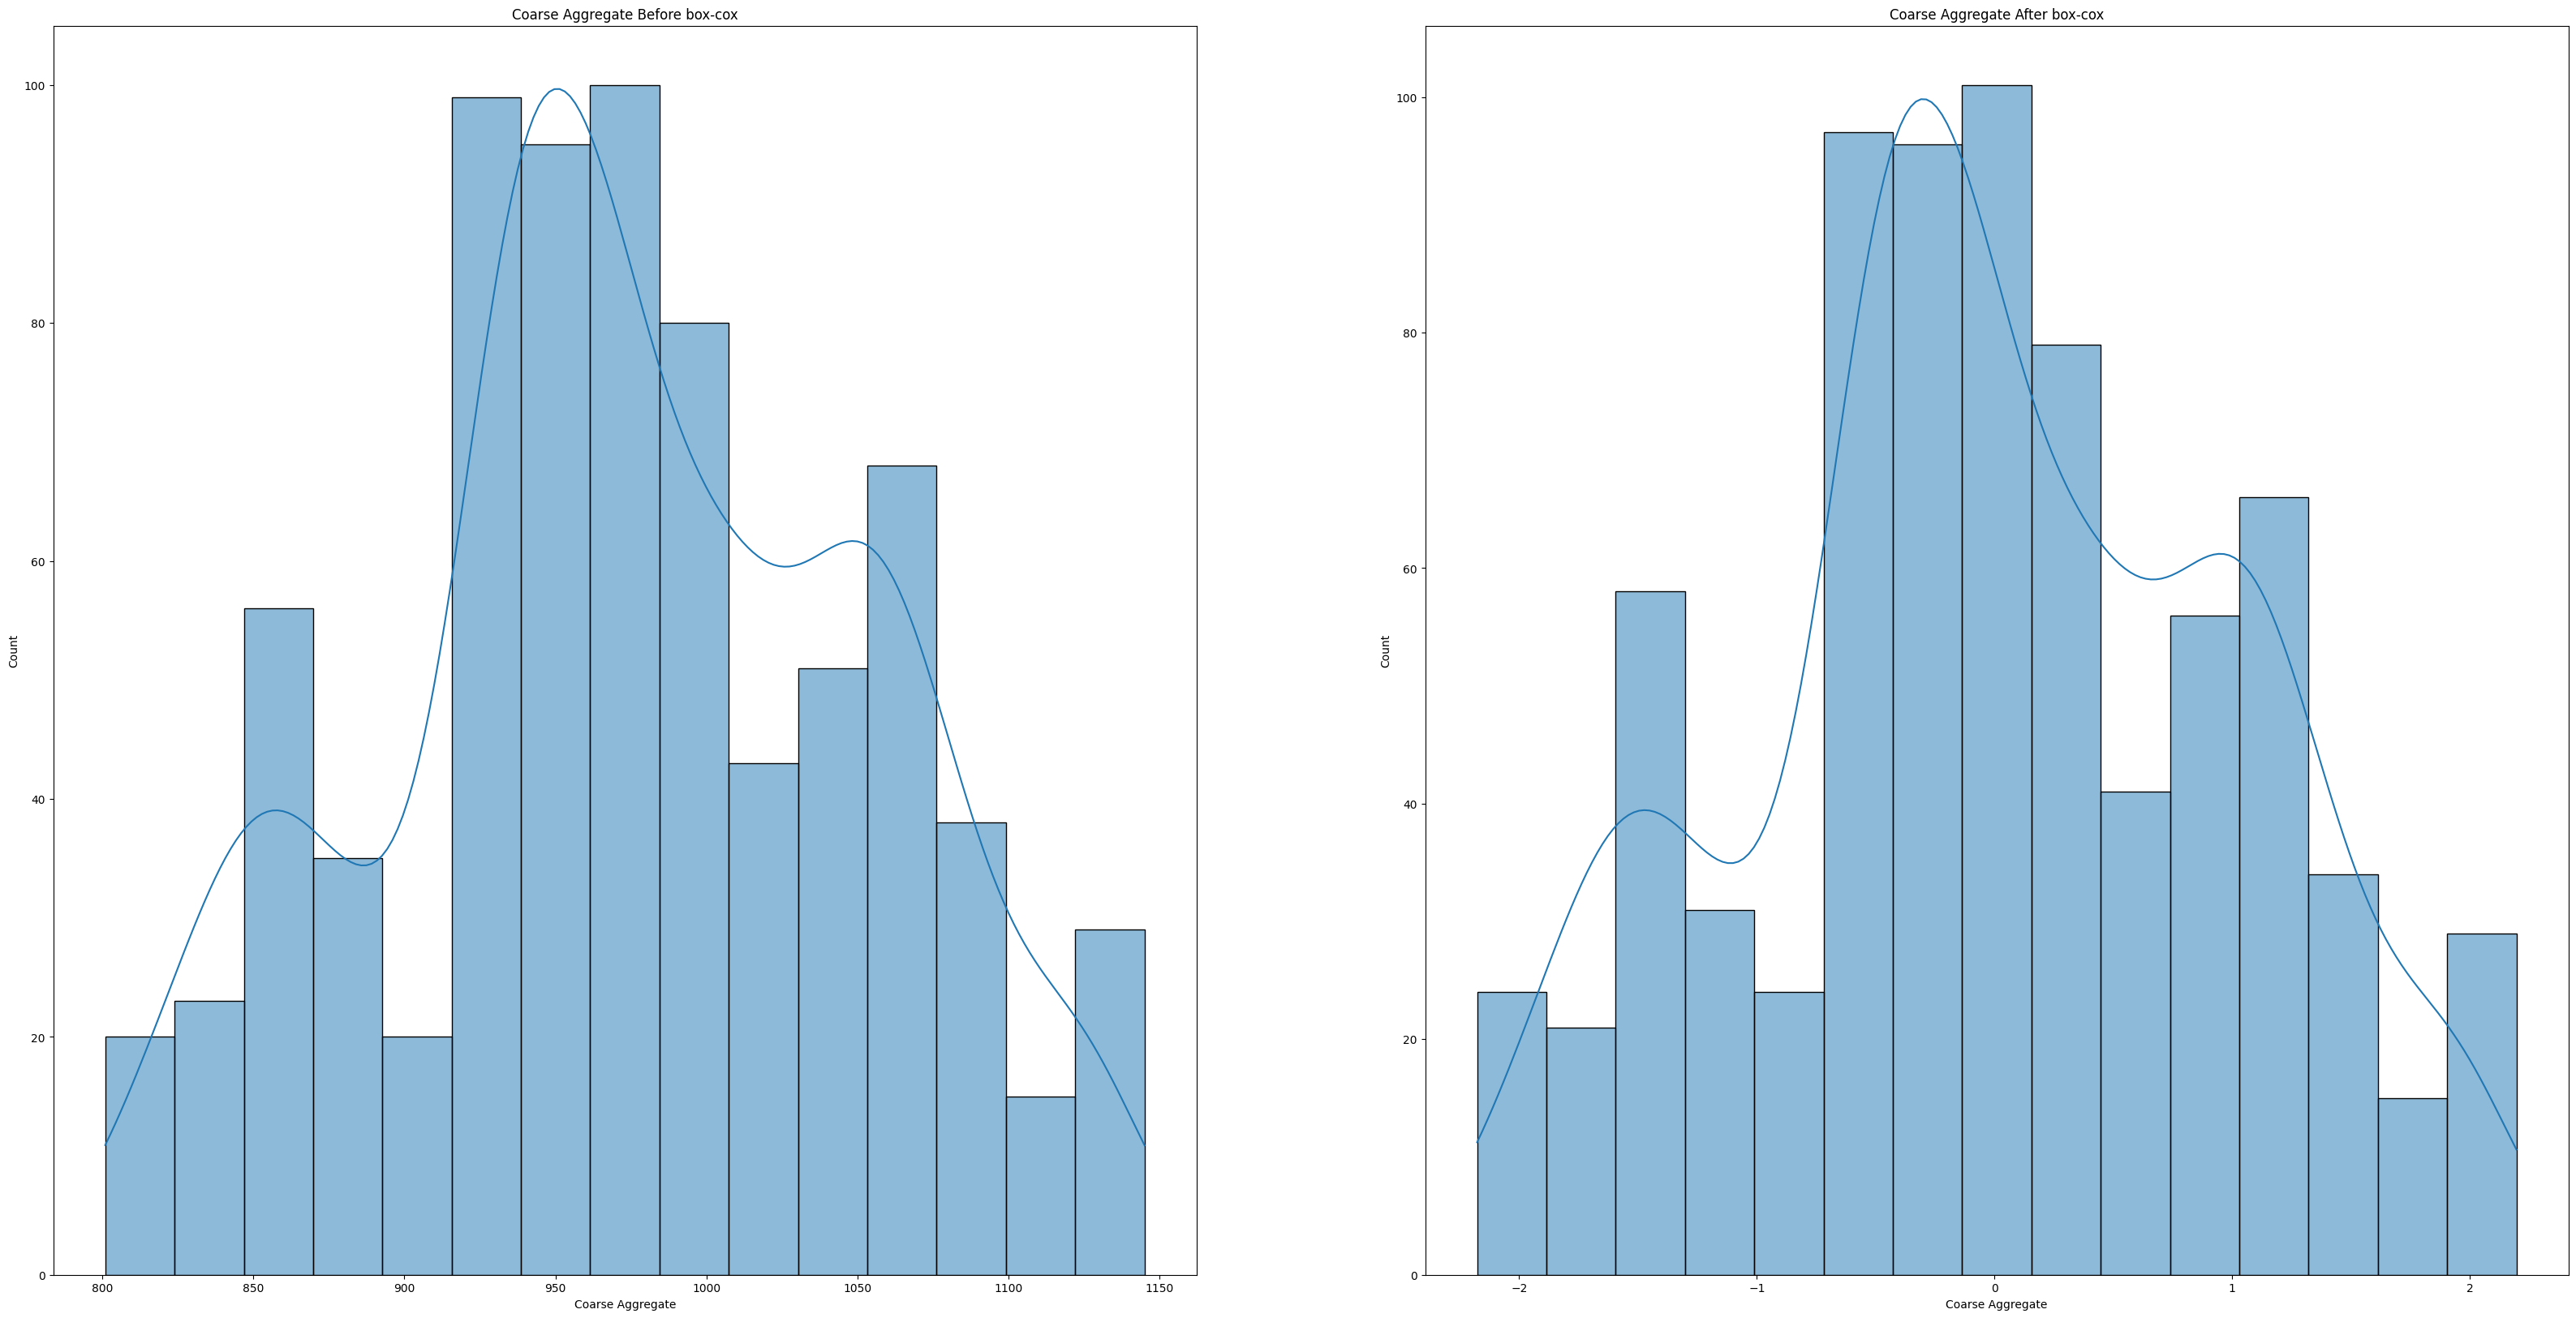

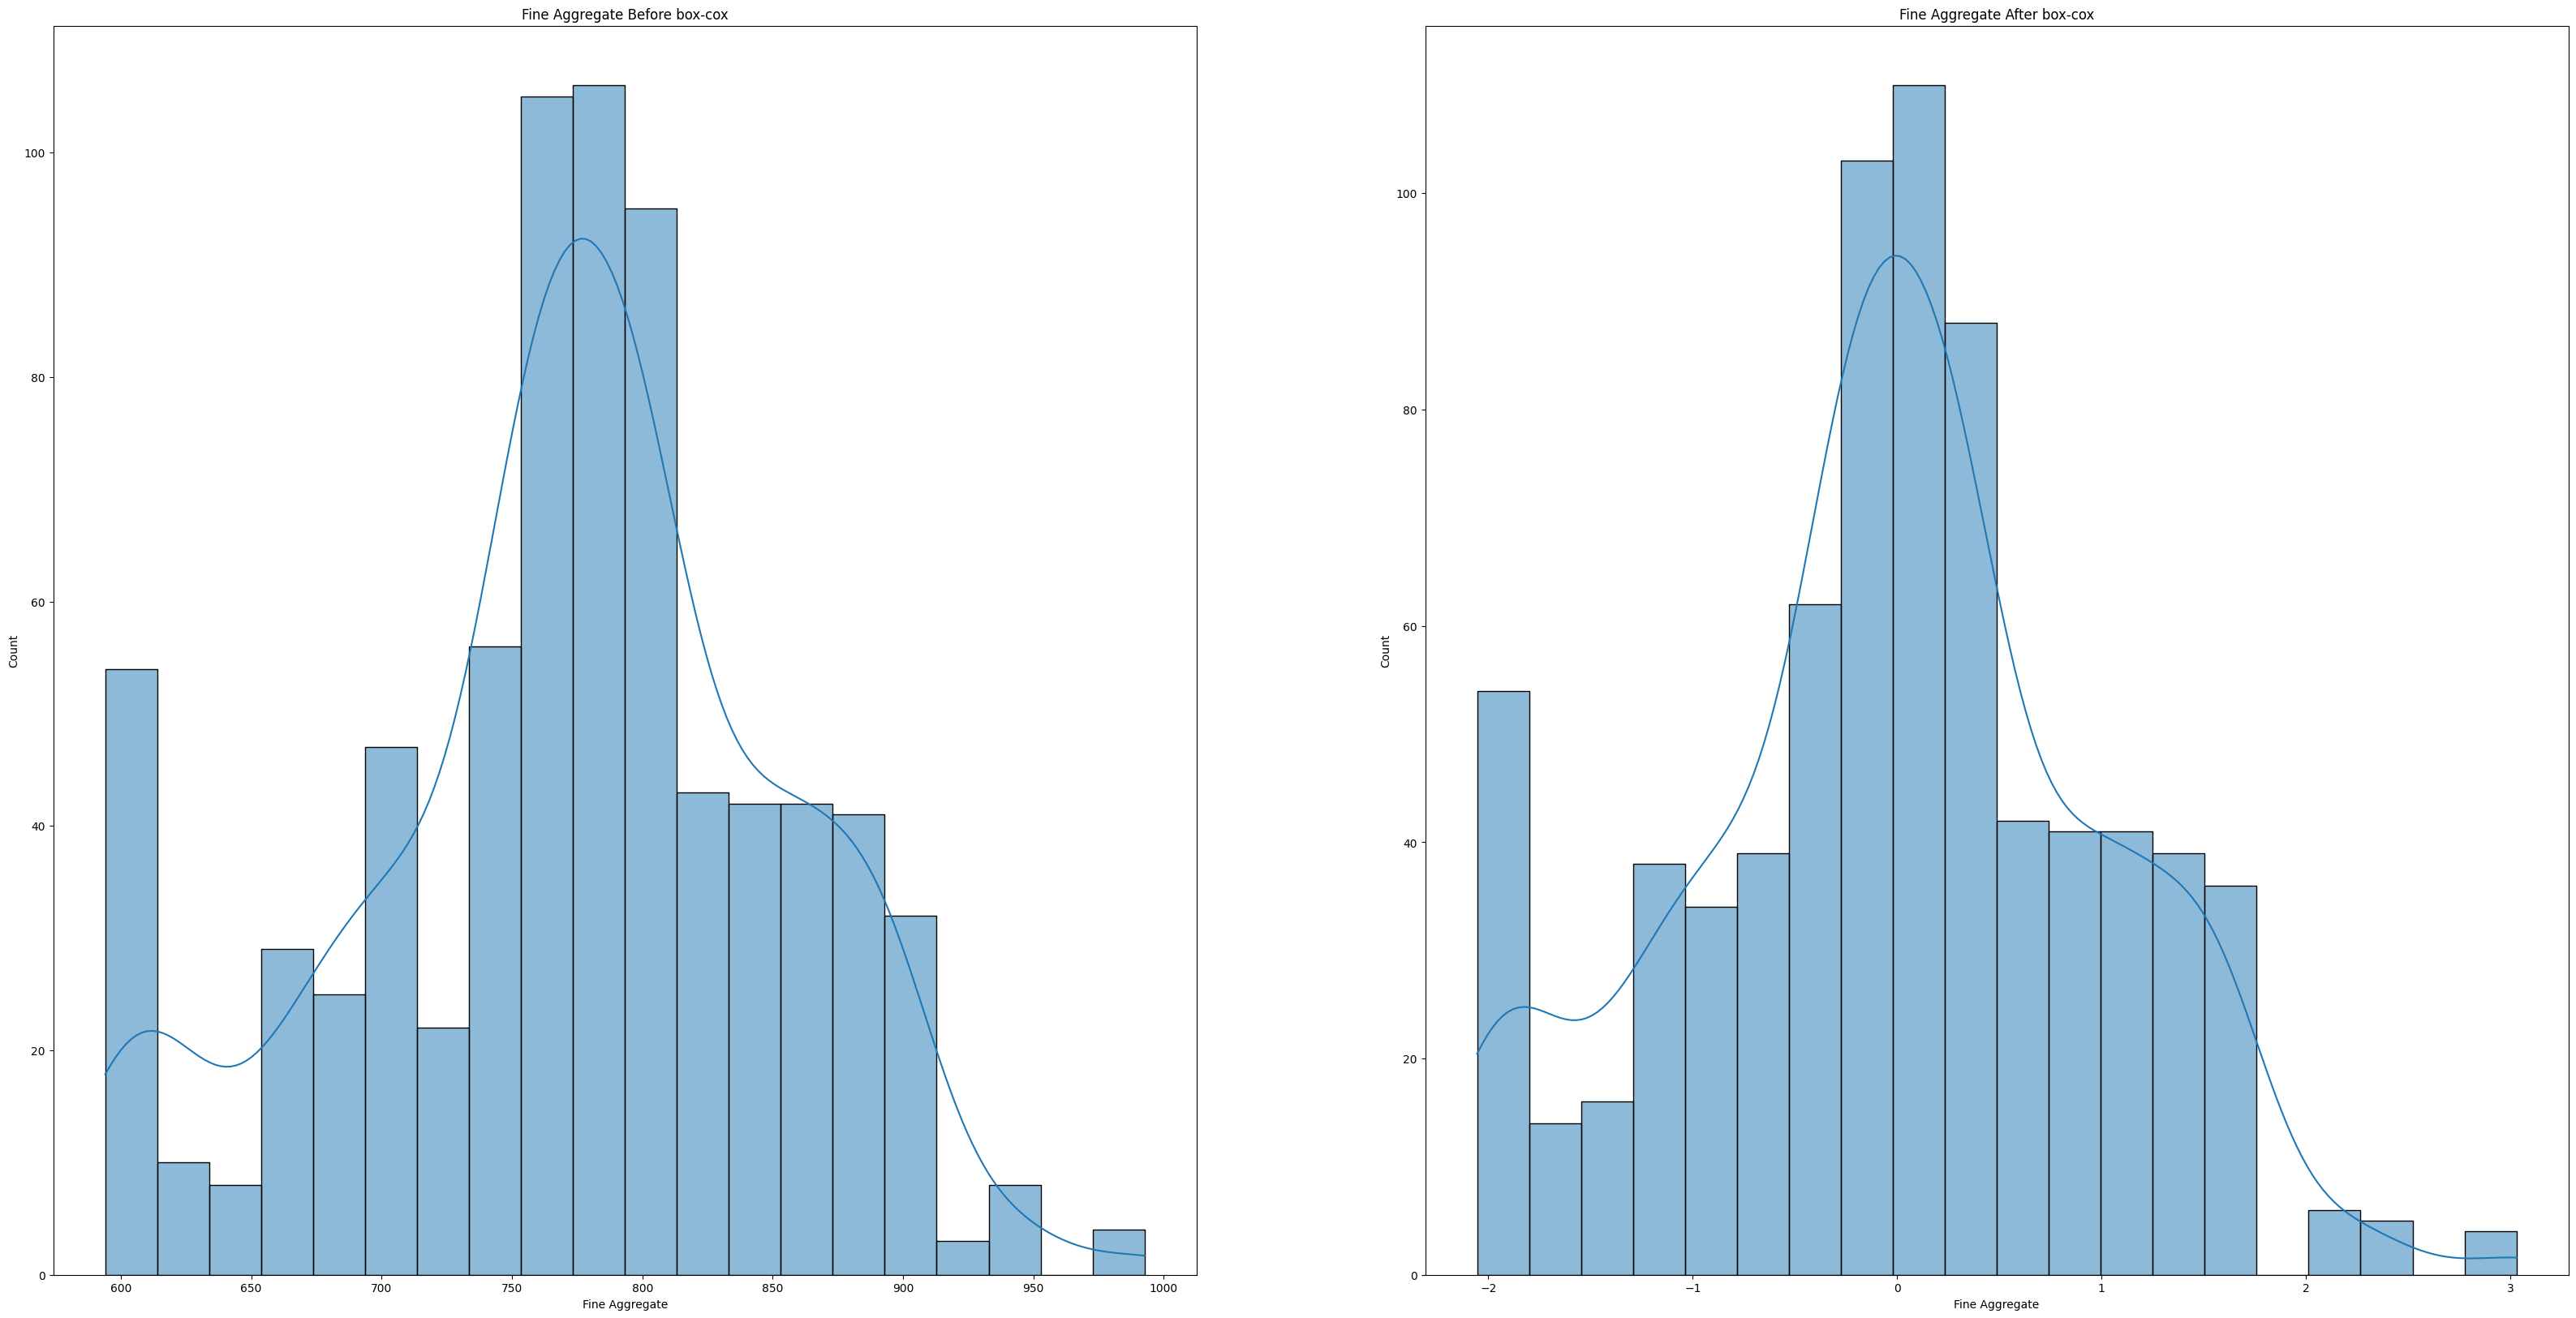

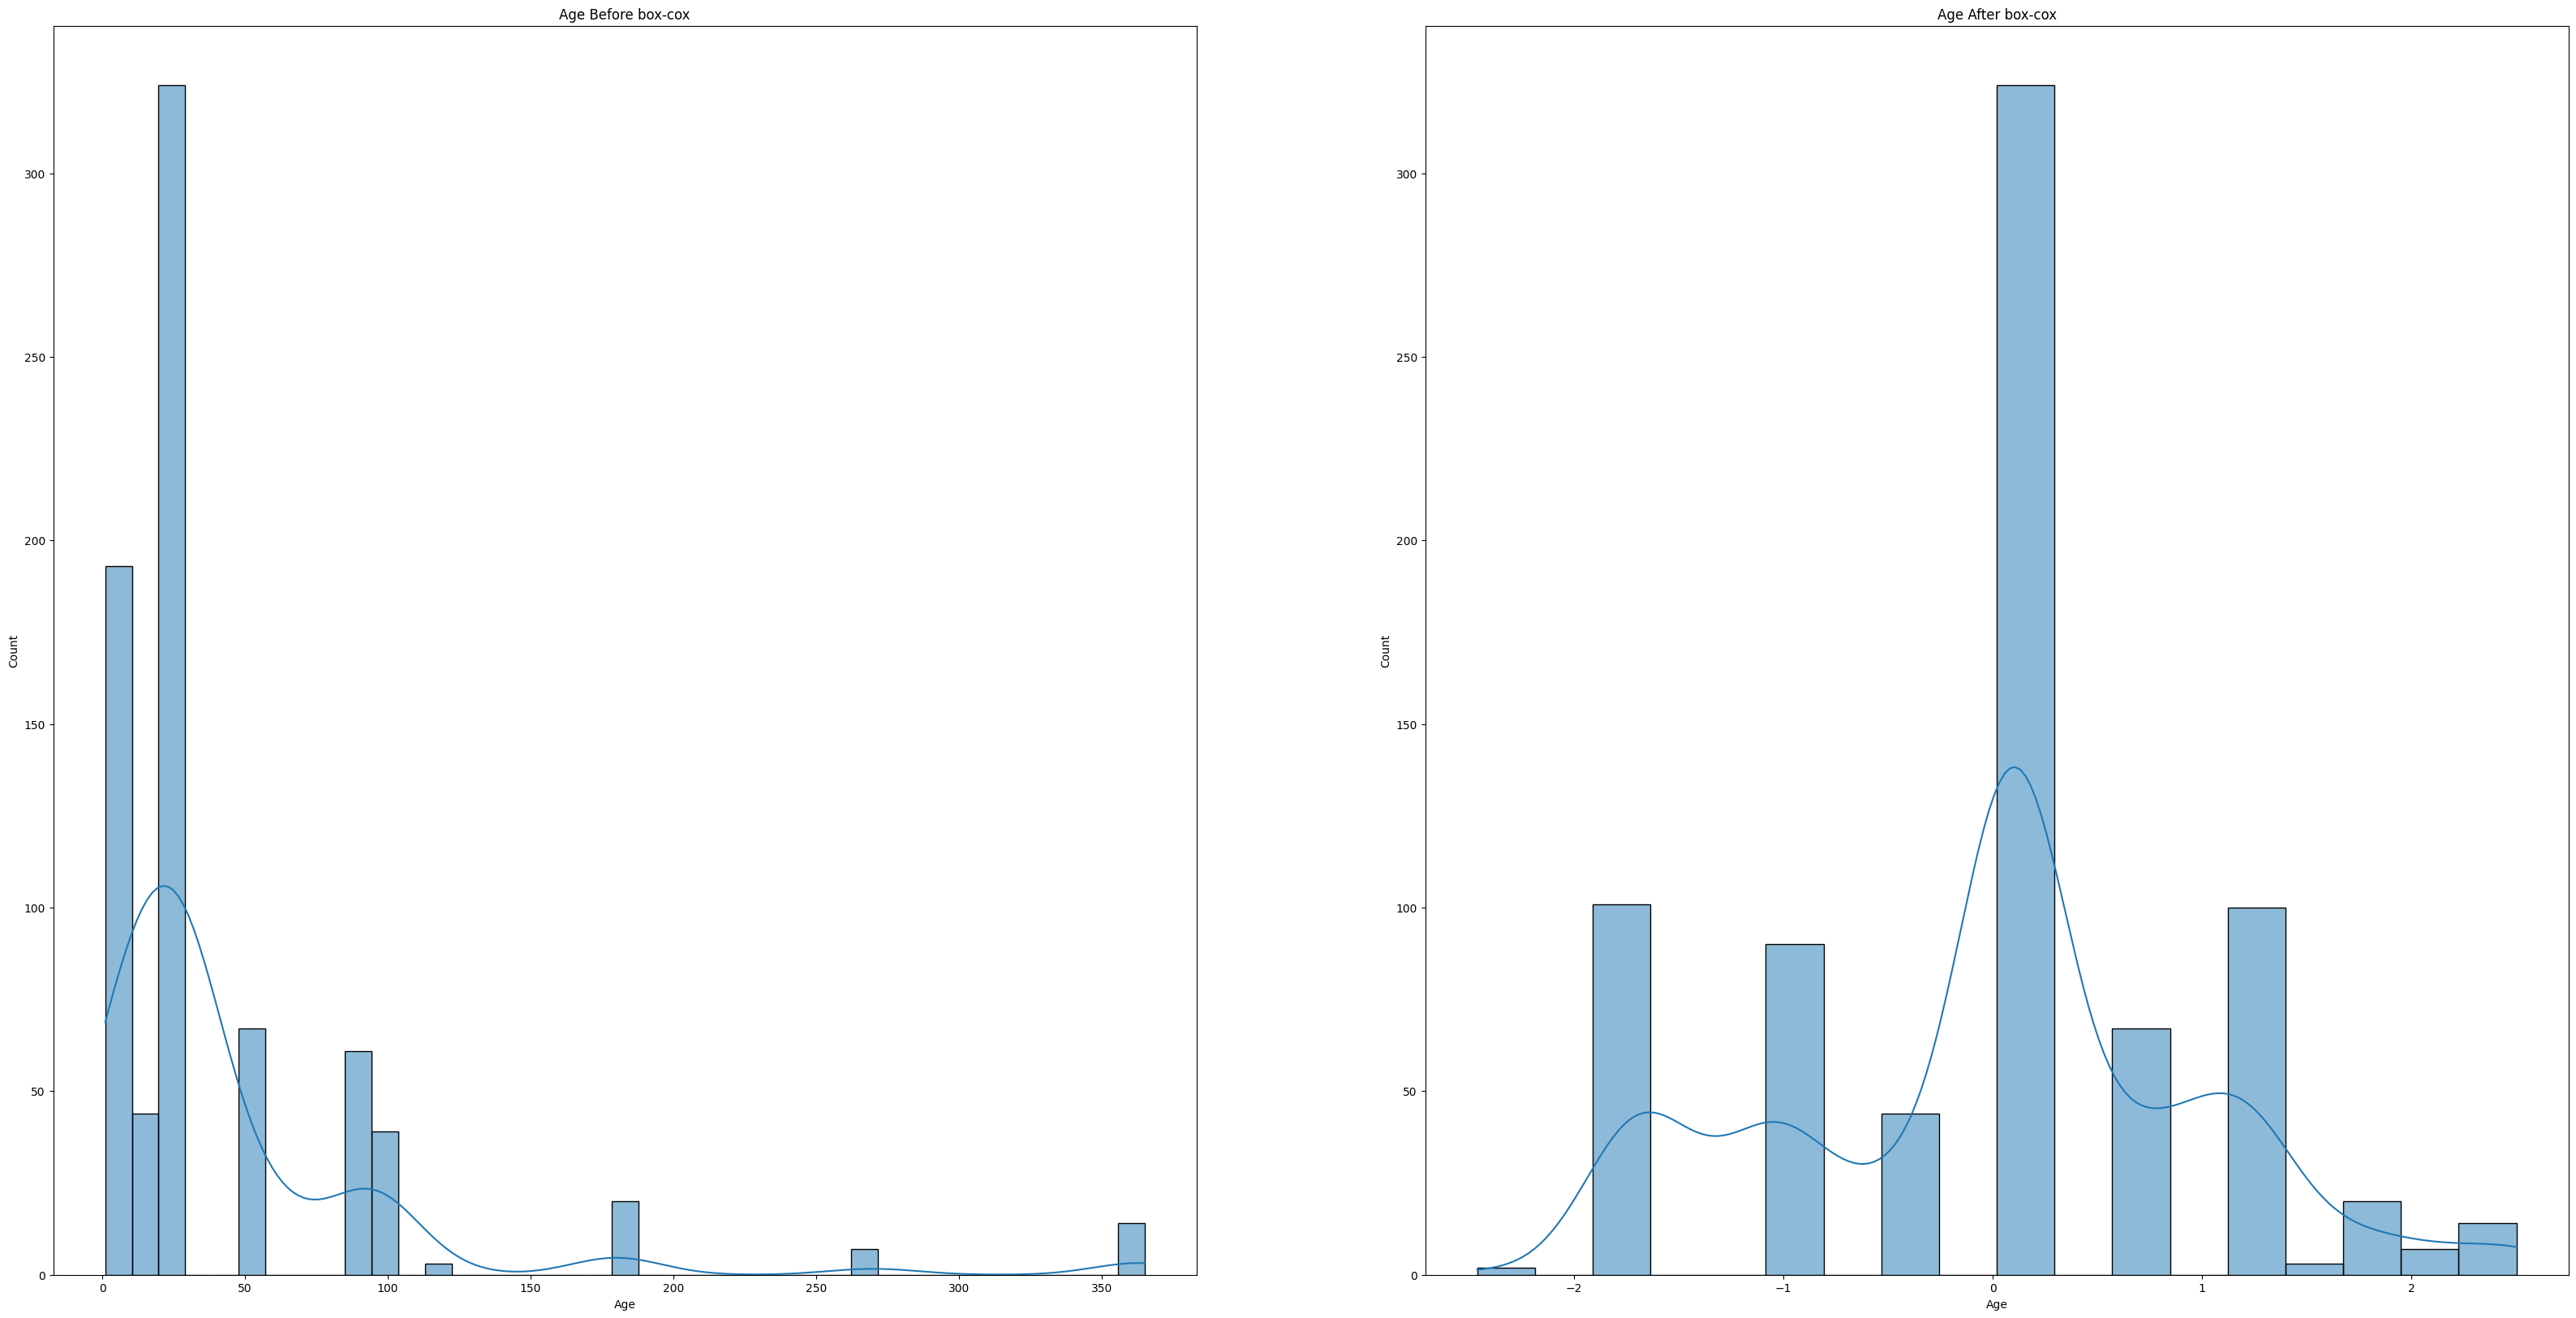

Test R2: 0.7953053654096063
CV R2: 0.6587712208873275


In [103]:
transformer('box-cox')